## Basics

In [1]:
#import relevant libraries
import os
from scipy import stats
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm
import seaborn as sns
import dabest
import NLCLIMB
import NLMATH
import itertools
from datetime import datetime
date = datetime.today().strftime('%Y%m%d')
from statistics import mean
from textwrap import wrap
import dabest
import plotly.express as px 
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.graph_objects import Layout
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import osar 

#NOTE: SUPPRESSES WARNINGS!

import warnings
warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

print(osar.__version__)

Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████| 11/11 [00:00<00:00, 19.82it/s]


Numba compilation complete!
0.23.7


In [2]:
officecomp = "C:\\Users\\Star\\"
labcomp = "C:\\Users\\User\\"
computer2 = "C:\\Users\\lnico\\"
homecomp = "D:\\"
specifiedpath = homecomp
filedate = "20251014"

filedirectory_OSAR = "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\2025collection\\"
filedirectory_Falling = "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\Compilation with delta\\2025deltagcollection\\"
filesavedir = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Totalosarfalling\\images\\"

In [3]:
#for fonts only
import matplotlib.pyplot as plt
from matplotlib import font_manager

font_dirs = [specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\"]  # The path to the custom font file.
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)


for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
    prop = font_manager.FontProperties(fname=font_file)

availablefonts = [f.name for f in matplotlib.font_manager.fontManager.ttflist]
plt.rcParams["font.family"] = "Inter"

## Function

In [4]:
def find_number(df, lookup_value, genre):
    lobe_values = []
    for _, row in df.iterrows():
        # Splitting the 'MBON' values and removing any potential whitespace
        mbon_values = [x.strip() for x in row['MBON names'].split(',')]
        if lookup_value in mbon_values:
            lobe_values.append(row[genre])
            
    lobelobe = list(set(lobe_values))
    return ', '.join(lobelobe)

def MBONnamefile(MBONList, pathfile):
    #reading mbonlist file

    #MBONFILEDIRECTORY: specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\"
    directorynew = os.path.dirname(os.path.dirname(pathfile)) #goes up one directory
    fileinnewdirc = os.listdir(directorynew)

    for file_no2 in fileinnewdirc:
        if ".csv" in file_no2:
            ff = os.path.join(directorynew, file_no2)
            csvfile = pd.read_csv(ff)

    csvfile = csvfile.astype('string')

    for n, k in zip(["B", "y", "a"], ['β', "γ", "α"]):
        csvfile['Lobe'] = csvfile['Lobe'].str.replace(n, k)

    lobelocation = pd.DataFrame()

    for m in MBONList:
        lobeloc = pd.DataFrame()
        lobeloc['MBON'] = [m]
        loclst = find_number(csvfile, m, "Lobe")
        mbonlst = find_number(csvfile, m, "MBON number").strip()
        ntlst = find_number(csvfile, m, "Neurotransmitter")
        lobeloc['Lobe_location'] = [loclst]
        lobeloc['MBON number'] = [mbonlst]
        lobeloc['Neurotransmitter'] = [ntlst]
        
        lobelocation = pd.concat([lobelocation, lobeloc])

    lobelocation = lobelocation.reset_index(drop=True)
    return lobelocation

def matchingdfs (df, matchingset):
    newdf_a = pd.DataFrame()
    for n in matchingset:
        df_a=pd.DataFrame()
        df_a = df[(df['MBON'] == n)]
        newdf_a = pd.concat([newdf_a, df_a]).reset_index(drop=True)
    return newdf_a

import textwrap

def wrap_labels(ax, width, break_long_words=False):
    labels = []
    for label in ax.get_xticklabels():
        text = label.get_text()
        labels.append(textwrap.fill(text, width=width,
                      break_long_words=break_long_words))
    ax.set_xticklabels(labels, rotation=0)
    
def matchinglobesets(dfreg_a, lobelocation):
    lobelocation_a = lobelocation.sort_values(by=['MBON']).reset_index(drop=True)
    dfreg_a_withloc = dfreg_a.sort_values(by=['MBON']).reset_index(drop=True)
    matchinglobereg = list(set(lobelocation_a['MBON']) & set(dfreg_a_withloc['MBON']))

    dflobe_reg = matchingdfs(lobelocation_a, matchinglobereg).sort_values(by=['MBON']).reset_index(drop=True)

    dfreg_a_withloc['Lobe_location'] = dflobe_reg['Lobe_location']
    dfreg_a_withloc['MBON number'] = dflobe_reg['MBON number']
    dfreg_a_withloc['Neurotransmitter'] = dflobe_reg['Neurotransmitter']

    return dfreg_a_withloc

def matchingcomp(dfreg_Cr2, osar_multiplot_cr2):
    matchingset = list(set(dfreg_Cr2['MBON']) & set(osar_multiplot_cr2['MBON']))
    newdf_a = pd.DataFrame()
    for n in matchingset:
        df_a=pd.DataFrame()
        df_a = dfreg_Cr2[(dfreg_Cr2['MBON'] == n)]
        df_b = pd.merge(df_a, osar_multiplot_cr2, on = "MBON" )
        newdf_a = pd.concat([newdf_a, df_b]).reset_index(drop=True)
        


## Formulas to run


In [5]:
newfile2 = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\Compilation with delta\\2025fallingtoosarcomp\\"
files2 = os.listdir(newfile2)


#mbon locations
MBONList = []
for yy in files2:
    MBONList.append(yy.split(" ")[0])

MBONList = list(set(MBONList))

lobelocation = MBONnamefile(MBONList, specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\")

## Heatmap of all light intensities

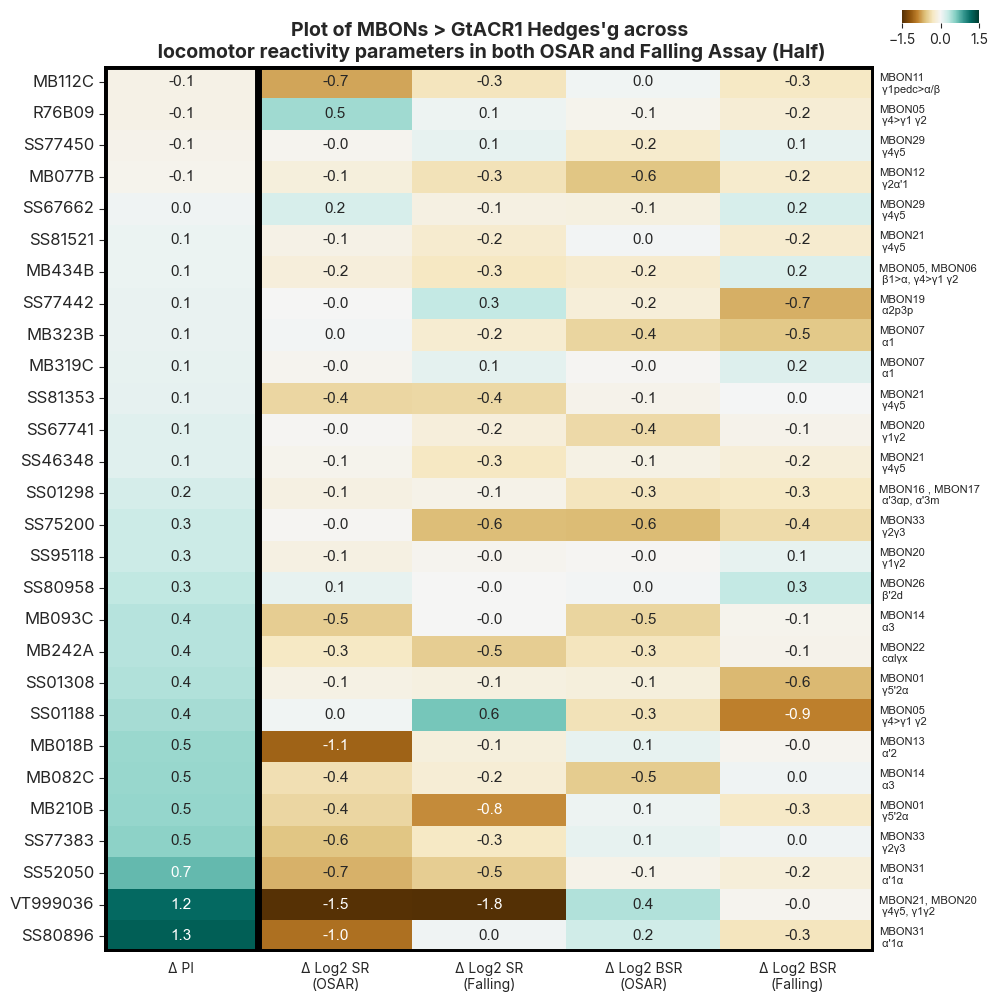

Generated heatmap for Half condition


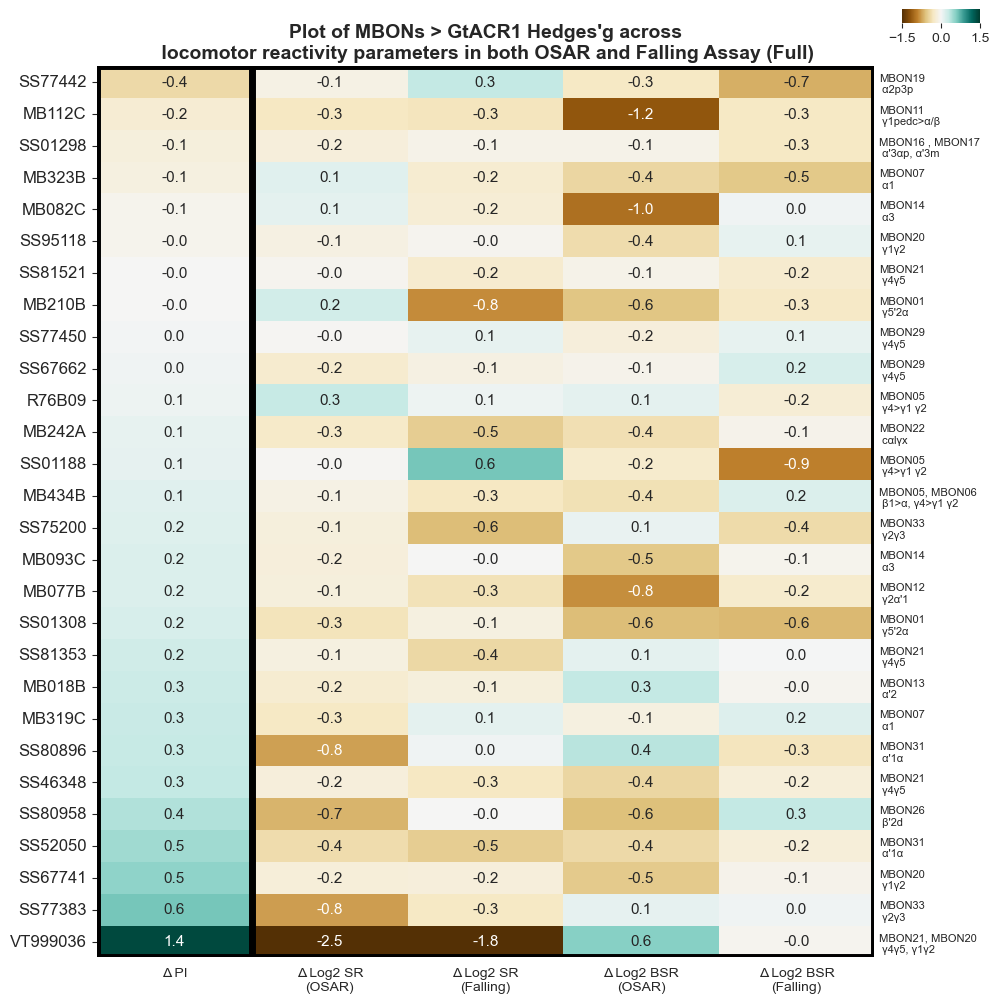

Generated heatmap for Full condition


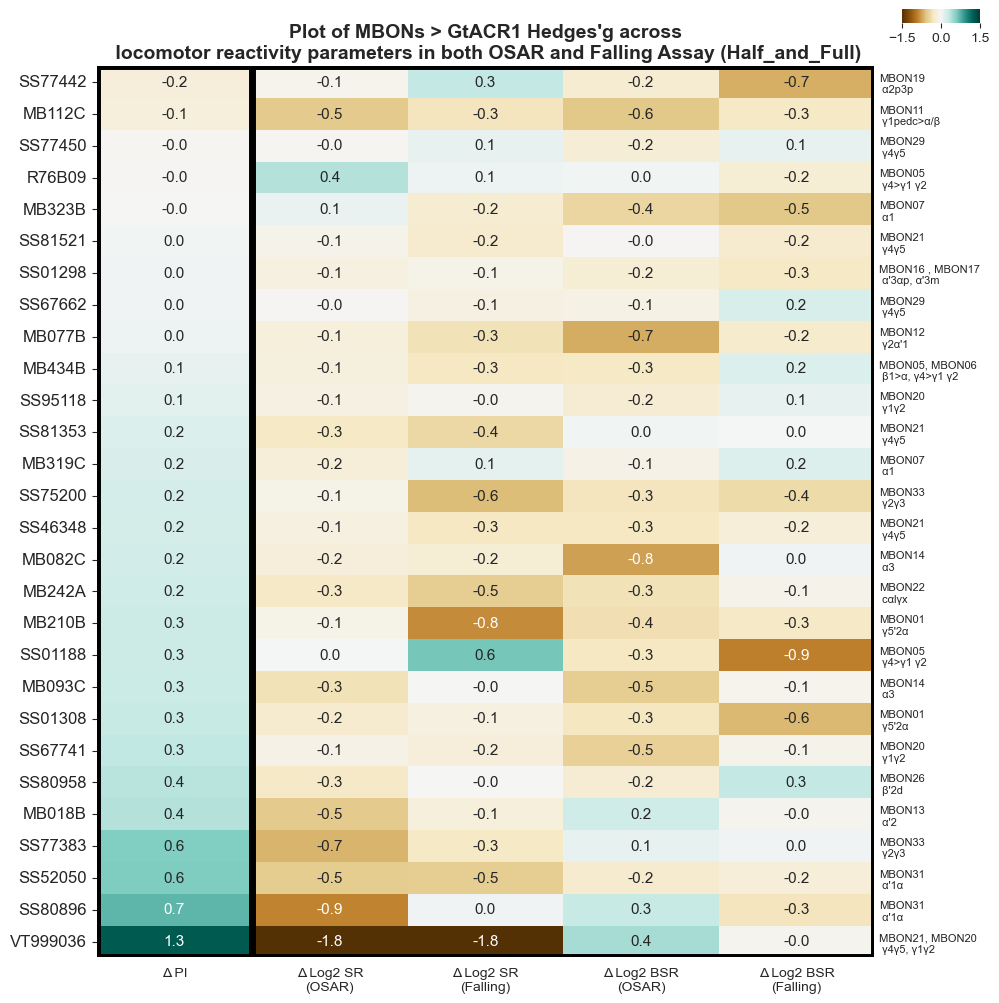

Generated heatmap for Half_and_Full condition


In [24]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

responder = "ACR"

plt.rcParams["font.family"] = "Inter"

# Define the three condition files
conditions = ['Half', 'Full', 'Half_and_Full']

for condition in conditions:
    # Read the specific condition file
    totalmetriccomparison = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Totalcomparisonofallmetrics-" + condition + ".xlsx")
    
    osarmatchdf = totalmetriccomparison.copy()
    
    if responder == 'Chrimson2':
        responderrename = "CsChrimson"
        df_specificmbon = osarmatchdf[osarmatchdf['responder']=="Chrimson2"].sort_values(by="PI_Δg_OSAR", ascending=True).reset_index(drop=True)
        colormap = 'RdGy'
    
    if responder == 'ACR':
        responderrename = "GtACR1"
        df_specificmbon = osarmatchdf[osarmatchdf['responder']=="ACR"].sort_values(by="PI_Δg_OSAR", ascending=True).reset_index(drop=True)
        colormap = 'BrBG'
    
    df00 = df_specificmbon.set_index(['genotypeandresponder'])
    
    fig1, ax3 = plt.subplots(figsize=(10,10))     
    
    # Adding extra axes label
    lobloclst = []
    mbonloclst = []
    df500 = df00.copy()
    for n in df00['MBON']:    
        lobloclst.append(lobelocation[lobelocation['MBON'] == n]['Lobe_location'].values[0])
        mbonloclst.append(lobelocation[lobelocation['MBON'] == n]['MBON number'].values[0])
    df500['Lobe'] = lobloclst
    df500['Name'] = mbonloclst
    
    df00 = df00.drop(['MBON', 'responder'], axis=1)
    
    # Single responder labeling
    newdf500 = pd.DataFrame()
    naming = df500['Name'].to_frame().rename(columns={"Name": ""})
    lobing = df500['Lobe'].to_frame().rename(columns={"Lobe": ""})
    newlabel = (naming.values + "\n " + lobing.values).tolist()
    newdf500['Merge'] = newlabel
    
    # New labels for heatmap
    df00 = df00[['PI_Δg_OSAR', 'Log2 Speed ratio_Δg_OSAR', 'Log2 Speed ratio_Δg_Falling', 
                 'Log2 Bout Speed ratio_Δg_OSAR', 'Log2 Bout Speed ratio_Δg_Falling']]
    xticklabeldf = df00.rename(columns={
        'PI_Δg_OSAR': 'Δ PI',
        'Log2 Speed ratio_Δg_OSAR': "Δ Log2 SR (OSAR)",
        'Log2 Bout Speed ratio_Δg_OSAR': "Δ Log2 BSR (OSAR)",
        'Log2 Bout Speed ratio_Δg_Falling': 'Δ Log2 BSR (Falling)',
        'Log2 Speed ratio_Δg_Falling': 'Δ Log2 SR (Falling)'
    })
    xticklabellist = xticklabeldf.columns.tolist()
    yticklabels = [label.split("_")[0] for label in df00.index]
    
    # Colorbar
    cax = inset_axes(ax3,
                     width="10%",
                     height="1.5%",
                     loc='lower right',
                     bbox_to_anchor=(0.1, 1.08, 1, 1),
                     bbox_transform=ax3.transAxes,
                     borderpad=-2,
                     )
    
    sns.set_style("whitegrid", {'axes.grid': False})           
    j7 = sns.heatmap(df00, ax=ax3, annot=True, fmt=".1f", vmin=-1.5, vmax=1.5, cmap=colormap, 
                     linewidths=0.0, edgecolor="none", xticklabels=xticklabellist, yticklabels=yticklabels,
                     clip_on=False, cbar_ax=cax, cbar_kws=dict(orientation="horizontal", ticks=[-1.5, 0, 1.5]), 
                     annot_kws={"size": 11})
    j7.set_ylabel('')
    j7.set_yticklabels(j7.get_yticklabels(), va='center', rotation=0, fontsize=12)
    j7.set_xticklabels(j7.get_xticklabels(), rotation=0, fontsize=10)
    wrap_labels(j7, 10)
    
    # Drawing the frame
    j7.axhline(y=0, color='k', linewidth=5) 
    j7.axhline(y=len(df00), color='k', linewidth=5) 
    j7.axvline(x=0, color='k', linewidth=5) 
    j7.axvline(x=1, color='k', linewidth=5) 
    j7.axvline(x=len(df00.columns), color='k', linewidth=5) 
    
    # Secondary axes
    j8 = j7.twinx()
    j8.set_ylim([0, j7.get_ylim()[0]])
    j8.set_yticks(j7.get_yticks())
    j8.tick_params(length=0)
    
    # Y labels for mbon lobes and naming
    labellinglist = newdf500['Merge'].iloc[::-1]
    labelledlist = []
    for n in labellinglist:
        labelledlist.extend(n)
        
    j8.set_yticklabels(labelledlist, fontsize=8)
    j8.spines['top'].set_visible(False)
    j8.spines['right'].set_visible(False)
    j8.spines['bottom'].set_visible(False)
    j8.spines['left'].set_visible(False)
    
    j7.set_title(f"Plot of MBONs > {responderrename} Hedges'g across\n locomotor reactivity parameters in both OSAR and Falling Assay ({condition})", 
                 x=0.5, weight='bold', fontsize=14)
    
    fig1.tight_layout()
    
    plt.savefig(filesavedir + date + "_" + responder + "_hedgesgheatmap_" + condition + ".png", dpi=1200)
    plt.savefig(filesavedir + date + "_" + responder + "_hedgesgheatmap_" + condition + ".svg")
    
    plt.show()
    
    print(f"Generated heatmap for {condition} condition")

## Heatmap comparing all PIs of OSAR conditions

In [6]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

responder = "Chrimson2"

plt.rcParams["font.family"] = "Inter"

# Define the three condition files
conditions = ['Eighth','Quarter','Half', 'Full']

lightintensitycheck = pd.DataFrame()

for condition in conditions:
    # Read the specific condition file
    totalmetriccomparison = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\OSAR and Falling_delta Log2SR and delta Log2BSR comparison-" + condition + ".xlsx")
    
    # Extract only MBON, genotypeandresponder, and Δ PI_OSAR columns
    temp_df = totalmetriccomparison[['MBON', 'genotypeandresponder', 'Δ PI_OSAR', 'Responder']].copy()
    
    # Rename the Δ PI_OSAR column to include the condition name
    temp_df = temp_df.rename(columns={'Δ PI_OSAR': f'Δ PI_OSAR-{condition}'})
    
    # Merge with the main dataframe
    if lightintensitycheck.empty:
        lightintensitycheck = temp_df
    else:
        lightintensitycheck = lightintensitycheck.merge(temp_df, on=['MBON', 'genotypeandresponder', 'Responder'], how='outer')


<Axes: ylabel='genotypeandresponder'>

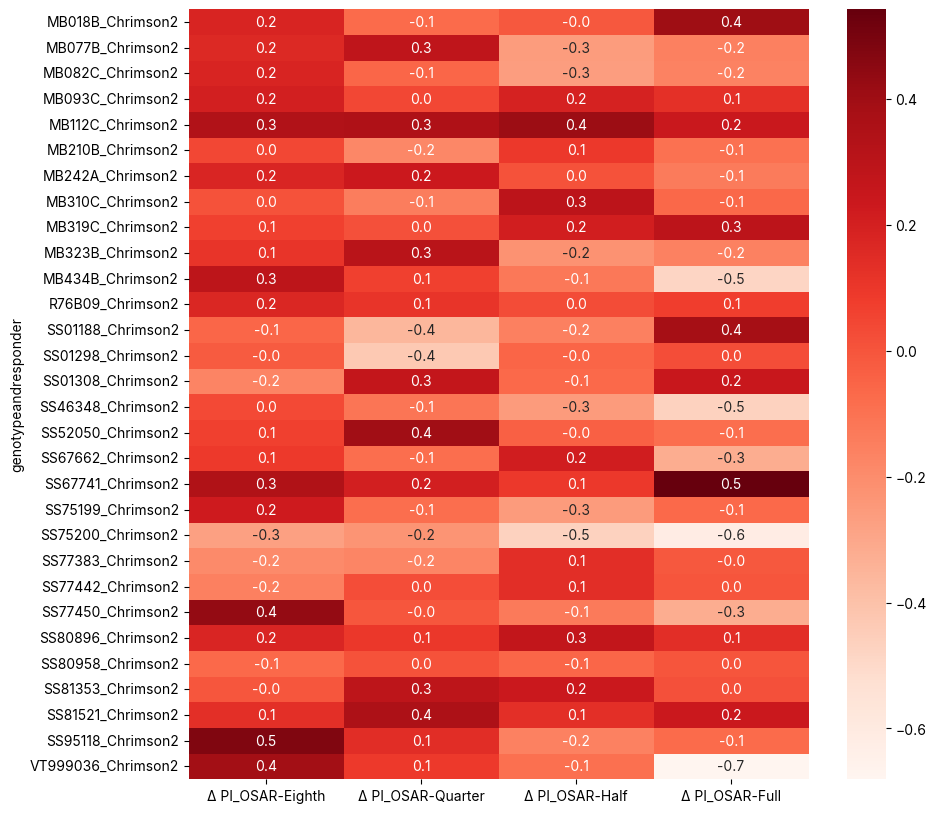

In [8]:
responder = "Chrimson2"

if responder == 'Chrimson2':
    responderrename = "CsChrimson"
    df_lightint = lightintensitycheck[lightintensitycheck['Responder']=="Chrimson2"]
    colormap = "Reds"


if responder == 'ACR':
    responderrename = "GtACR1"
    df_lightint = lightintensitycheck[lightintensitycheck['Responder']=="ACR"]
    colormap = "Greens"


totalpiheatmap = df_lightint.drop(columns=['Responder', 'MBON']).set_index('genotypeandresponder')
fig_heatmappi, ax_heatmappi = plt.subplots(figsize=(10,10))   
 
sns.heatmap(totalpiheatmap, ax=ax_heatmappi, annot=True, fmt=".1f", cmap = colormap)

## Valence signs reversal

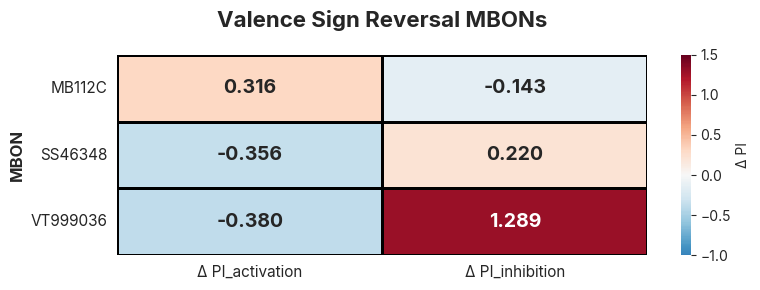

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


# Read the Excel files
osar_chrimson = pd.read_excel(homecomp + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\OSAR_Chrimson2.xlsx")
osar_acr = pd.read_excel(homecomp + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\OSAR_ACR.xlsx")

# Extract PI values from both files
activation_pi = osar_chrimson[['MBON', 'Δ PI']].copy()
activation_pi['MBON'] = activation_pi['MBON'].astype(str)
activation_pi = activation_pi.rename(columns={'Δ PI': 'Δ PI_activation'})

inhibition_pi = osar_acr[['MBON', 'Δ PI']].copy()
inhibition_pi['MBON'] = inhibition_pi['MBON'].astype(str)
inhibition_pi = inhibition_pi.rename(columns={'Δ PI': 'Δ PI_inhibition'})

# Create DataFrame for heatmap
heatmap_data = activation_pi.merge(inhibition_pi, how="inner", on= "MBON").set_index("MBON")
mbons_of_interest = ['MB112C', 'SS46348', 'VT999036']
heatmap_data = heatmap_data.loc[mbons_of_interest]

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 3))

# Create heatmap
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdBu_r', center=0, 
            cbar_kws={'label': 'Δ PI'}, 
            linewidths=2, linecolor='black',
            vmin=-1, vmax=1.5,
            annot_kws={'size': 14, 'weight': 'bold'})

# Customize plot
plt.title('Valence Sign Reversal MBONs', 
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('MBON', fontsize=12, fontweight='bold')
plt.xticks(rotation=0, fontsize=11)
plt.yticks(rotation=0, fontsize=11)

# Tight layout
plt.tight_layout()

# Save figure
plt.savefig(filesavedir + date + "_valencesigreveralmbons.png", dpi = 1200, bbox_inches='tight')

# Show plot
plt.show()




## Lin reg

In [12]:
def omission(df):
    tempdff = df[df['MBON'] != 'VT999036'].reset_index(drop=True) #removing outlier
    #dfomitted = tempdff[~((tempdff['PI_Δg_OSAR'].abs() < 0.2) & (tempdff['Log2 Bout Speed ratio_Δg_OSAR'].abs() < 0.2))]
    dfomitted = tempdff[~((tempdff['PI_Δg_OSAR'].abs() < 0.2) )]
   
    return dfomitted.reset_index(drop=True)

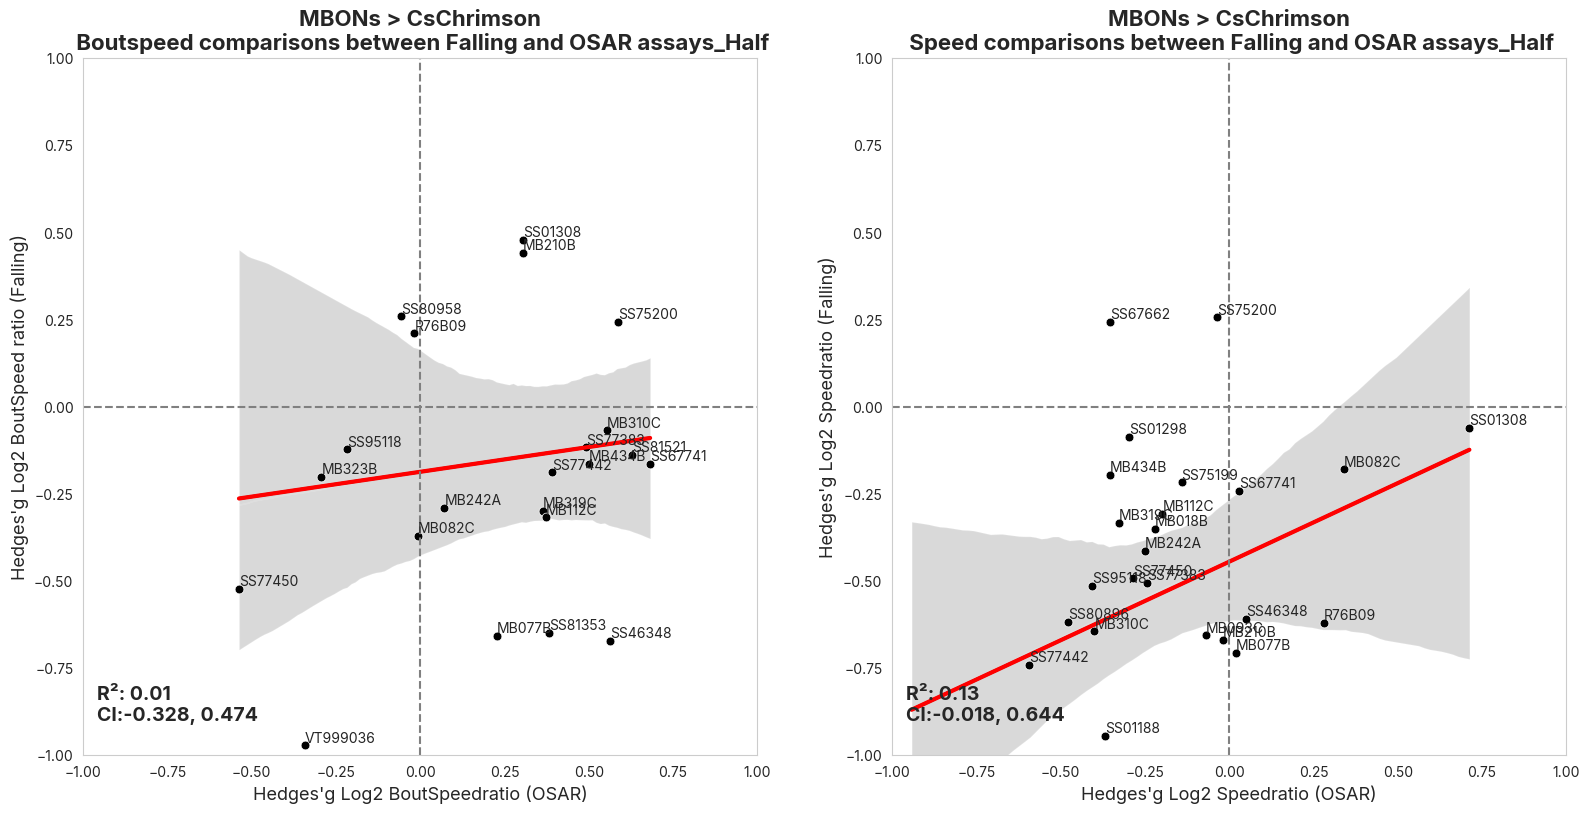

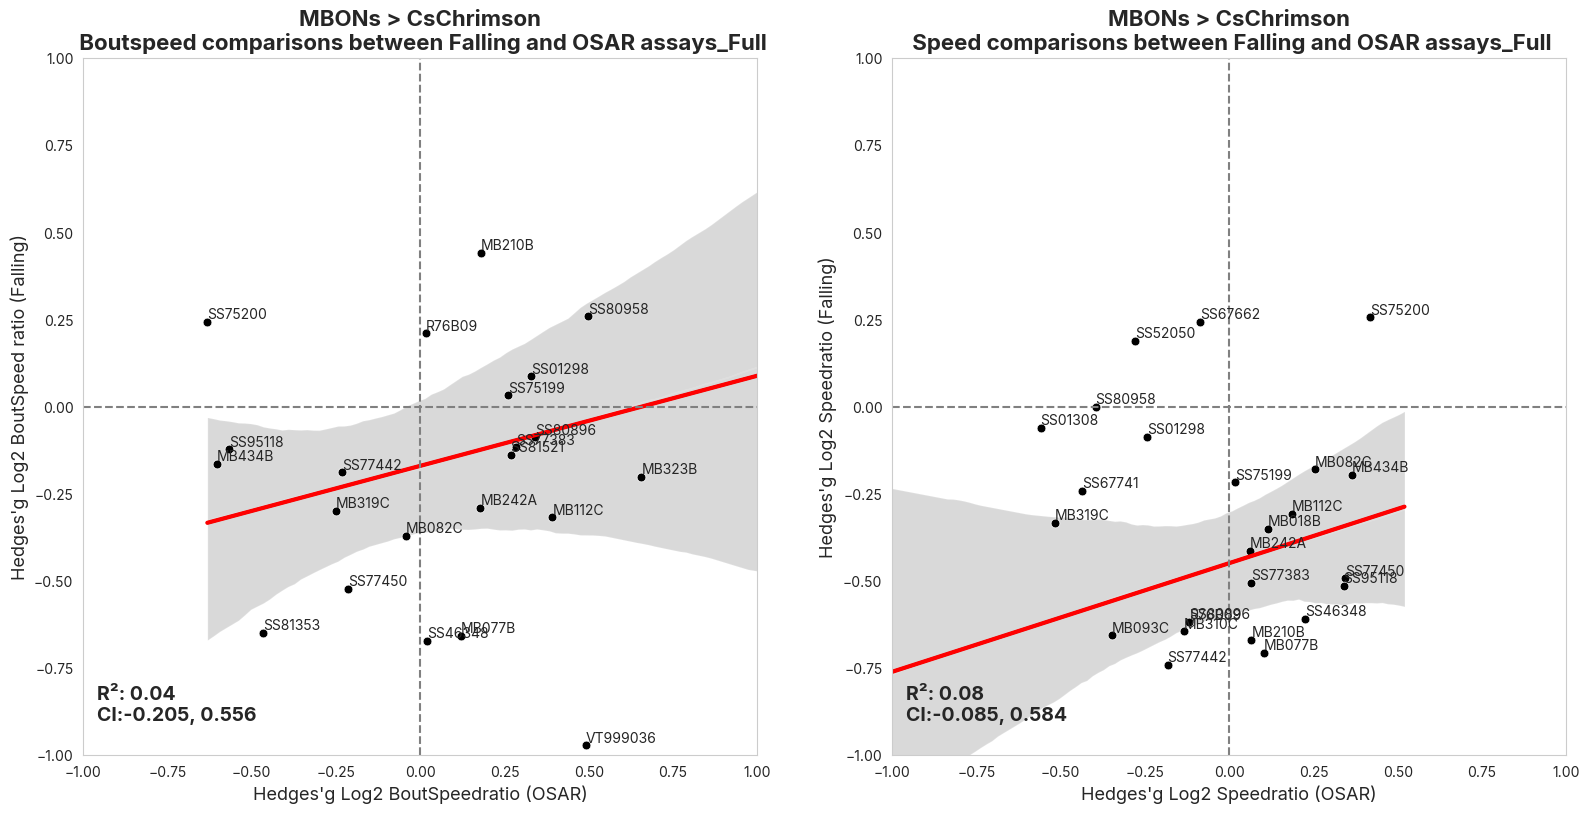

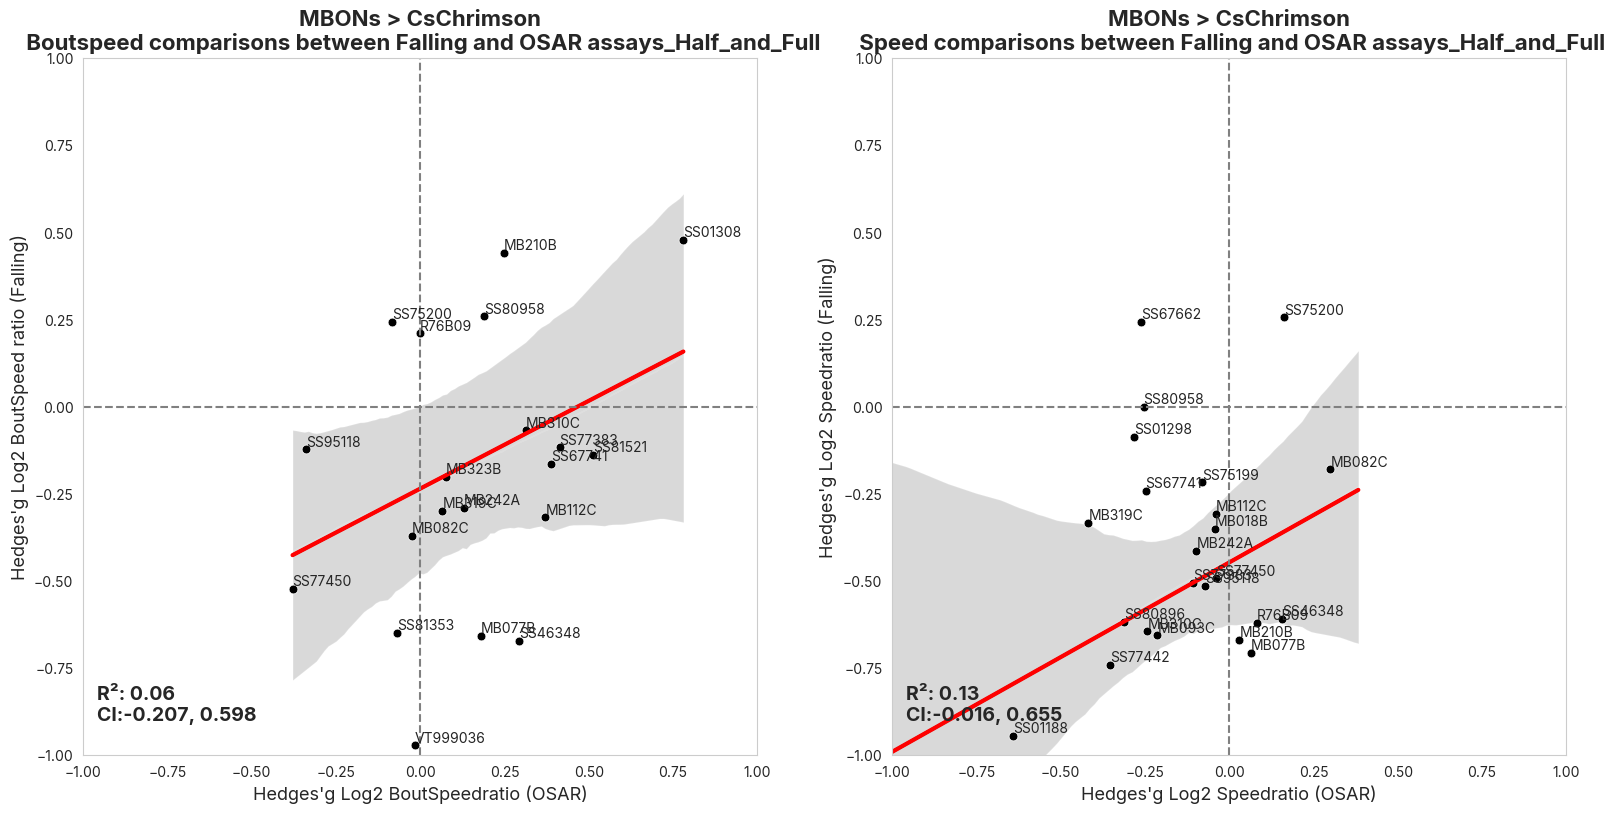

In [28]:
#only for values above magnitude of 0.2 and no VT999036
import scipy.stats

plt.rcParams["font.family"] = "Inter"

conditions = ['Half', 'Full', 'Half_and_Full']

for condition in conditions:
    # Read the specific condition file
    totalmetriccomparison = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Totalcomparisonofallmetrics-" + condition + ".xlsx")

    responder = "Chrimson2"

    if responder == 'Chrimson2':
        responderrename = "CsChrimson"
        df_specificmbon = totalmetriccomparison[totalmetriccomparison['responder']=="Chrimson2"].sort_values(by = "PI_Δg_OSAR", ascending=True).reset_index(drop=True)
        colorline = "#ff0000"

    if responder == 'ACR':
        responderrename = "GtACR1"
        df_specificmbon = totalmetriccomparison[totalmetriccomparison['responder']=="ACR"].sort_values(by = "PI_Δg_OSAR", ascending=True).reset_index(drop=True)
        colorline = "#14962c"

    figosarplot, axscatter_o = plt.subplots(1, 2, figsize=(16, 8), gridspec_kw={"width_ratios":[1,1]})

    # First subplot
    x_label_1 = "Log2 Bout Speed ratio_Δg_OSAR"
    y_label_1 = 'Log2 Bout Speed ratio_Δg_Falling'

    df02omitteddf = df_specificmbon[~((df_specificmbon[x_label_1].abs() < 0.2) & (df_specificmbon[y_label_1].abs() < 0.2))].reset_index(drop=True)

    sns.regplot(x=x_label_1, y=y_label_1, data=df02omitteddf, ci = 95, scatter = False, line_kws={"color": "black"}, ax=axscatter_o[0]) #ci color
    sns.regplot(x=x_label_1, y=y_label_1, data=df02omitteddf, ci = 0, scatter = False, line_kws={"color": colorline, 'lw': 3}, ax=axscatter_o[0])  #line color
    sns.scatterplot(x=x_label_1, y=y_label_1, data=df02omitteddf, s = 40, color = 'k', ax=axscatter_o[0])

    axscatter_o[0].set_xlabel("Hedges'g Log2 BoutSpeedratio (OSAR)", fontsize = 13)
    axscatter_o[0].set_ylabel("Hedges'g Log2 BoutSpeed ratio (Falling)", fontsize = 13)
    axscatter_o[0].grid(False)
    axscatter_o[0].set_ylim([-1, 1])
    axscatter_o[0].set_xlim([-1, 1])
    axscatter_o[0].axvline(0, c=(.5, .5, .5), ls= '--')
    axscatter_o[0].axhline(0, c=(.5, .5, .5), ls= '--')
    axscatter_o[0].set_title("MBONs > " + responderrename + "\n Boutspeed comparisons between Falling and OSAR assays_" + condition, weight = "bold", fontfamily = "Inter", fontsize = 16)
    axscatter_o[0].yaxis.set_tick_params(labelbottom=True)

    for n, k in enumerate(df02omitteddf['MBON']):
        axscatter_o[0].annotate(k, (df02omitteddf.loc[n,x_label_1], df02omitteddf.loc[n,y_label_1]+0.01), fontsize = 10)

    #correlation for first subplot
    pearsonscorrelation_cr2_1 = scipy.stats.pearsonr(df02omitteddf[x_label_1], df02omitteddf[y_label_1]) #correlation instead of linear regression: trying to find the relationship rather than causation    
    civallow_cr2_1 = pearsonscorrelation_cr2_1.confidence_interval(confidence_level=0.95)[0] 
    civalhigh_cr2_1 = pearsonscorrelation_cr2_1.confidence_interval(confidence_level=0.95)[1]  
    axscatter_o[0].annotate(f"R²: {(round(pearsonscorrelation_cr2_1[0],3))**2:.2f}" + "\nCI:" + str(round(civallow_cr2_1,3)) + ", " + str(round(civalhigh_cr2_1,3)), (0.02, 0.05), 
                            ha = "left", xycoords = 'axes fraction', weight = "bold", fontsize = 14)


    # Second subplot
    x_label_2 = "Log2 Speed ratio_Δg_OSAR"
    y_label_2 = 'Log2 Speed ratio_Δg_Falling'
    
    df_omitted02_2ndplot = df_specificmbon[~((df_specificmbon[x_label_2].abs() < 0.2) & (df_specificmbon[y_label_2].abs() < 0.2))].reset_index(drop=True)
    
    sns.regplot(x=x_label_2, y=y_label_2, data=df_omitted02_2ndplot, ci = 95, scatter = False, line_kws={"color": "black"}, ax=axscatter_o[1]) #ci color
    sns.regplot(x=x_label_2, y=y_label_2, data=df_omitted02_2ndplot, ci = 0, scatter = False, line_kws={"color": colorline, 'lw': 3}, ax=axscatter_o[1]) #linecolor
    sns.scatterplot(x=x_label_2, y=y_label_2, data=df_omitted02_2ndplot, s = 40, color = 'k', ax=axscatter_o[1])

    axscatter_o[1].set_xlabel("Hedges'g Log2 Speedratio (OSAR)", fontsize = 13)
    axscatter_o[1].set_ylabel("Hedges'g Log2 Speedratio (Falling)", fontsize = 13)
    axscatter_o[1].grid(False)
    axscatter_o[1].set_ylim([-1, 1])
    axscatter_o[1].set_xlim([-1, 1])
    axscatter_o[1].axvline(0, c=(.5, .5, .5), ls= '--')
    axscatter_o[1].axhline(0, c=(.5, .5, .5), ls= '--')
    axscatter_o[1].set_title("MBONs > " + responderrename + "\n Speed comparisons between Falling and OSAR assays_" + condition, weight = "bold", fontsize = 16)
    axscatter_o[1].yaxis.set_tick_params(labelbottom=True)

    for n, k in enumerate(df_omitted02_2ndplot['MBON']):
        axscatter_o[1].annotate(k, (df_omitted02_2ndplot.loc[n,x_label_2], df_omitted02_2ndplot.loc[n,y_label_2]+0.01), fontsize = 10)

    #correlation for second subplot
    pearsonscorrelation_cr2_2 = scipy.stats.pearsonr(df_omitted02_2ndplot[x_label_2], df_omitted02_2ndplot[y_label_2]) #correlation instead of linear regression: trying to find the relationship rather than causation    
    civallow_cr2_2 = pearsonscorrelation_cr2_2.confidence_interval(confidence_level=0.95)[0] 
    civalhigh_cr2_2 = pearsonscorrelation_cr2_2.confidence_interval(confidence_level=0.95)[1]  
    axscatter_o[1].annotate(f"R²: {(round(pearsonscorrelation_cr2_2[0],3))**2:.2f}" + "\nCI:" + str(round(civallow_cr2_2,3)) + ", " + str(round(civalhigh_cr2_2,3)), (0.02, 0.05), 
                            ha = "left", xycoords = 'axes fraction', weight = "bold", fontsize = 14)

    plt.tight_layout()
    plt.subplots_adjust(top = 0.95, wspace=0.2)

    plt.savefig(filesavedir + date + "_" + responder + "_linreg_" + condition +".png", dpi = 1200, bbox_inches='tight')
    plt.savefig(filesavedir + date + "_" + responder + "_linreg_" + condition + ".svg")

## Clustering

weighted euclidean


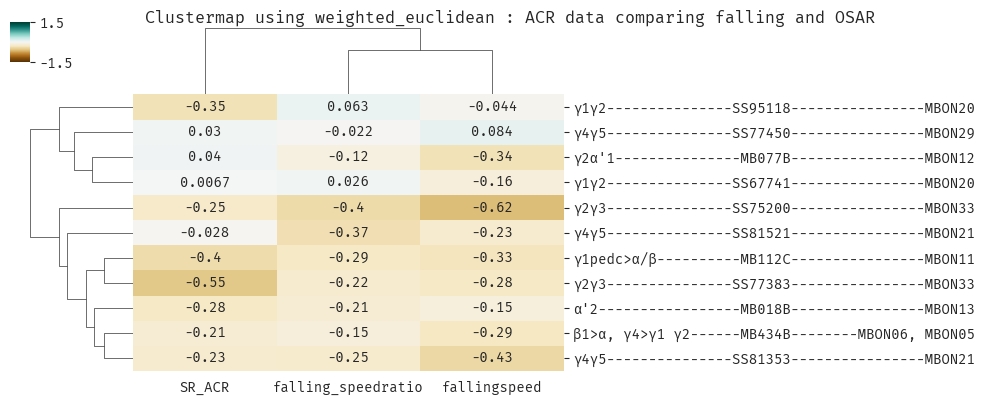

In [ ]:
methodlist = ['weighted']
metriclist = ['euclidean']
       
df601 = df600.copy()
df601['totalnaming'] = df601['MBON'] + "; " + df601['Name'] + "; " + df601['Lobe']
df601newset = df601.set_index('totalnaming').filter(items = ["falling_speedratio", "fallingspeed", "SR_ACR"])
plt.rcParams["font.family"] = "Inter"

ylabellist = []
for n, k, z in zip(df601['MBON'],df601['Lobe'], df601['Name']):
    ylabels = f"{k:-<18}{n:-^10}{z:->20}"
    ylabellist.append(ylabels)

for methodd in methodlist:
    for metricc in metriclist:
        print (methodd + " " + metricc)
        j7 = sns.clustermap(df601newset, cmap='BrBG', metric = metricc, method = methodd, yticklabels=ylabellist, vmin = -1.5, vmax=1.5, annot=True,
                            cbar_kws = dict(shrink = 0.15, ticks = [-1.5,1.5]), figsize=(10, 4), cbar_pos=(0, 0.87, .02, .1) ) #use_gridspec=False,location="bottom", shrink = 0.25, pad=0.01 #vmin = -1.5, vmax=1.5,
        ax = j7.ax_heatmap
        ax.set_ylabel('')
        ax.set_xticklabels(ax.get_xticklabels(), rotation = 0, fontsize = 10)
        wrap_labels(ax, 8)
        j7.fig.suptitle('Clustermap using ' + methodd + "_" + metricc + ' : ACR data comparing falling and OSAR' , weight='bold', fontsize =12, y =1.0)

        #plt.rcParams["font.family"] = "Inter"
        #plt.savefig(openPath + "images\\" + date + "_" + responder + "_clustermap_" + methodd + "_" + metricc + "_betweenChrimsonandACR.png", dpi = 1200)

## Comparison of PI against all types

In [50]:
data_nt

,Fall number_ΔΔ_Falling,Speed_Δg_Falling,Max height climbed_Δg_Falling,Bout speed_Δg_Falling,Pause position_Δg_Falling,Max velocity_Δg_Falling,Straightness Index_Δg_Falling,Duration of bouts_Δg_Falling,Number of Bouts_Δg_Falling,PI_Δg_OSAR,Log2 Speed ratio_Δg_OSAR,Log2 Bout Speed ratio_Δg_OSAR,Light Attraction Index_Δg_OSAR,Log2 Bout Speed ratio_Δg_Falling,Log2 Speed ratio_Δg_Falling
0,-0.339,-0.149,-0.242,-0.040,-0.433,-1.405,0.892,0.315,-0.424,0.263252,-0.213702,0.311855,-0.172942,-0.040,-0.149
1,0.015,-0.328,-0.005,-0.290,-0.182,-0.743,-0.554,-0.110,0.173,-0.203729,-0.300439,-1.167661,-1.037600,-0.290,-0.328
2,0.005,0.107,-0.008,0.159,0.020,0.135,0.300,0.496,-0.328,0.282885,-0.283194,-0.123929,0.021186,0.159,0.107
3,0.437,-0.213,-0.002,-0.546,-0.033,-0.247,0.529,-0.107,0.160,-0.125663,0.138486,-0.439056,-0.120391,-0.546,-0.213
4,-1.026,0.642,0.924,-0.912,1.136,-0.871,0.689,0.726,0.600,0.099859,-0.012550,-0.237911,-0.077928,-0.912,0.642
5,-0.450,-0.077,0.208,-0.285,0.266,-0.251,0.208,-0.007,0.005,-0.145638,-0.152413,-0.078215,-0.383610,-0.285,-0.077
6,-1.703,-0.121,0.345,-0.633,0.721,-1.006,1.741,1.098,-0.981,0.196644,-0.330567,-0.616350,0.539232,-0.633,-0.121
7,0.028,-0.294,-0.427,-0.166,-0.432,0.058,-0.215,-0.156,-0.206,0.310598,-0.157031,-0.434321,-0.007049,-0.166,-0.294
8,0.011,-0.508,-0.068,-0.167,-0.094,0.226,-0.135,-0.220,-0.006,0.466409,-0.397382,-0.417768,-0.293740,-0.167,-0.508
9,0.532,-0.112,0.097,0.192,0.006,-0.350,-0.474,0.017,0.035,0.043326,-0.233353,-0.061863,-0.068915,0.192,-0.112


In [55]:
metrictype

['Fall number_ΔΔ_Falling',
 'Speed_Δg_Falling',
 'Max height climbed_Δg_Falling',
 'Bout speed_Δg_Falling',
 'Pause position_Δg_Falling',
 'Max velocity_Δg_Falling',
 'Straightness Index_Δg_Falling',
 'Duration of bouts_Δg_Falling',
 'Number of Bouts_Δg_Falling',
 'MBON',
 'PI_Δg_OSAR',
 'Log2 Speed ratio_Δg_OSAR',
 'Log2 Bout Speed ratio_Δg_OSAR',
 'Light Attraction Index_Δg_OSAR',
 'Log2 Bout Speed ratio_Δg_Falling',
 'Log2 Speed ratio_Δg_Falling']

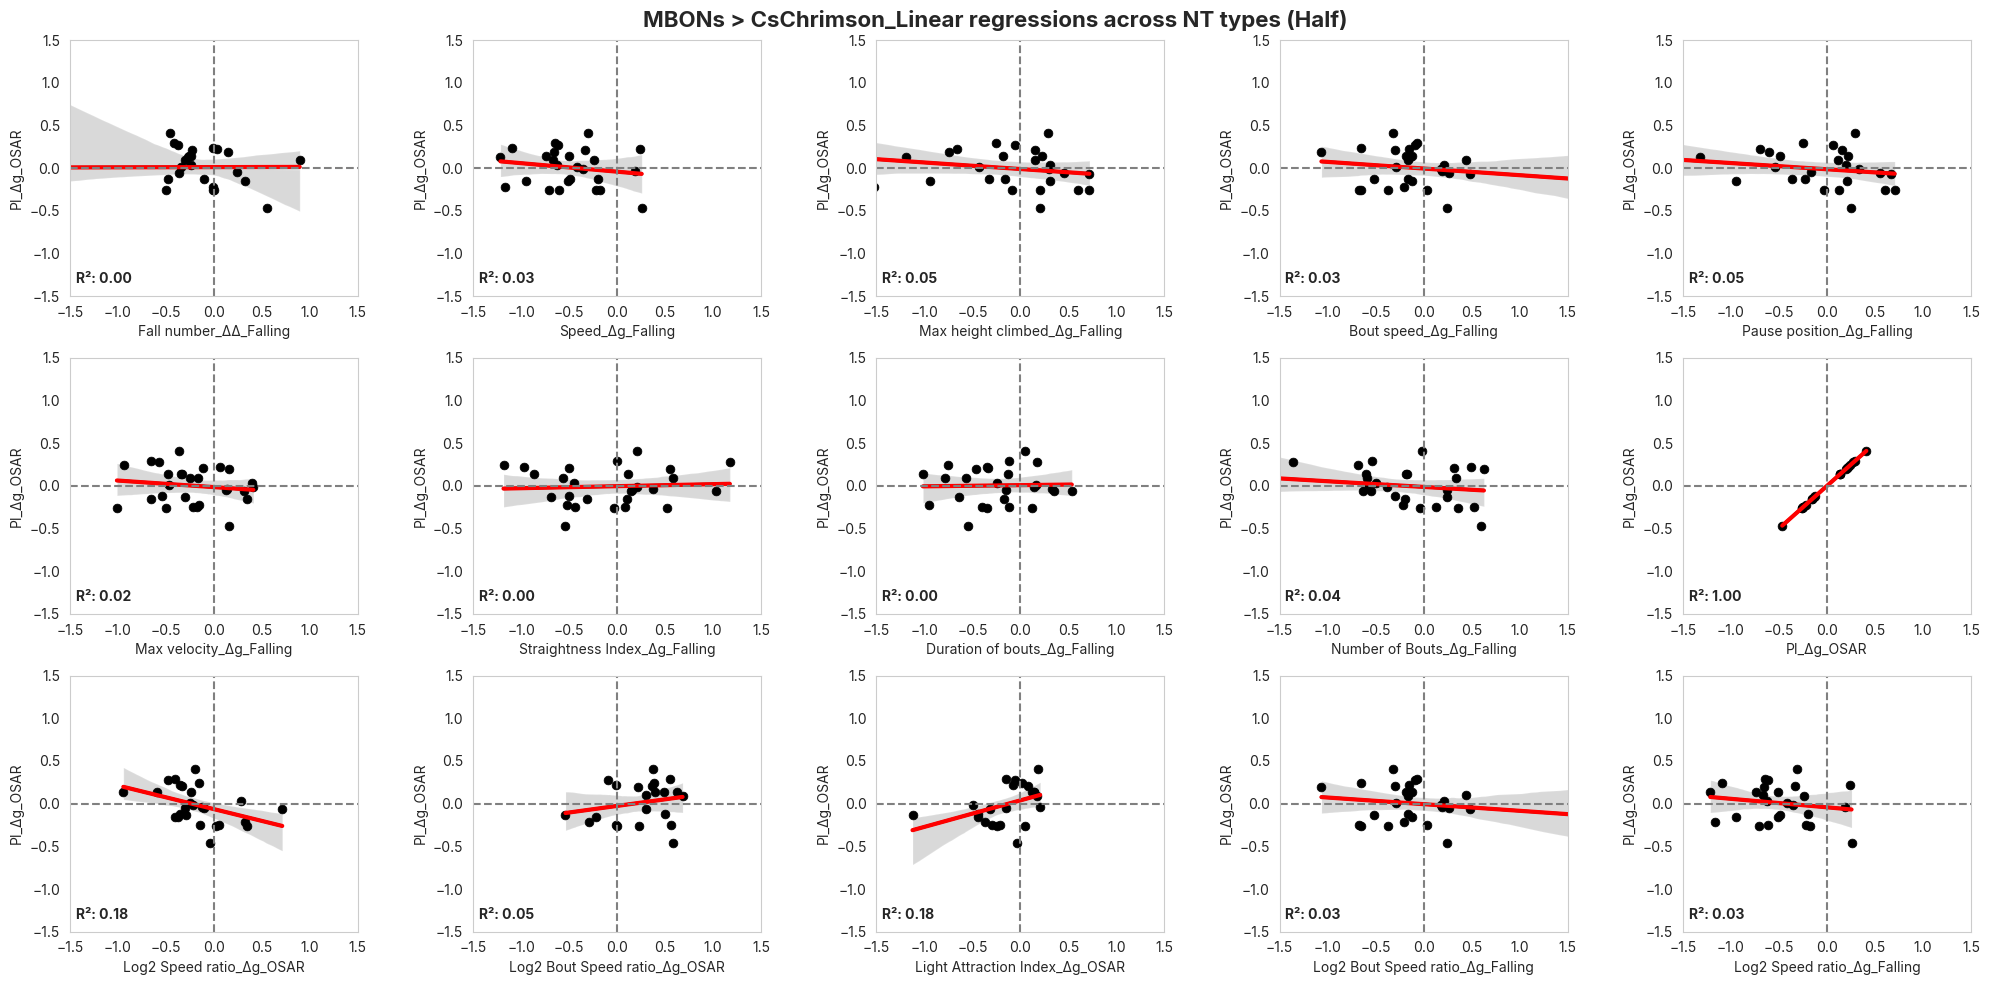

Generated plot for Half condition


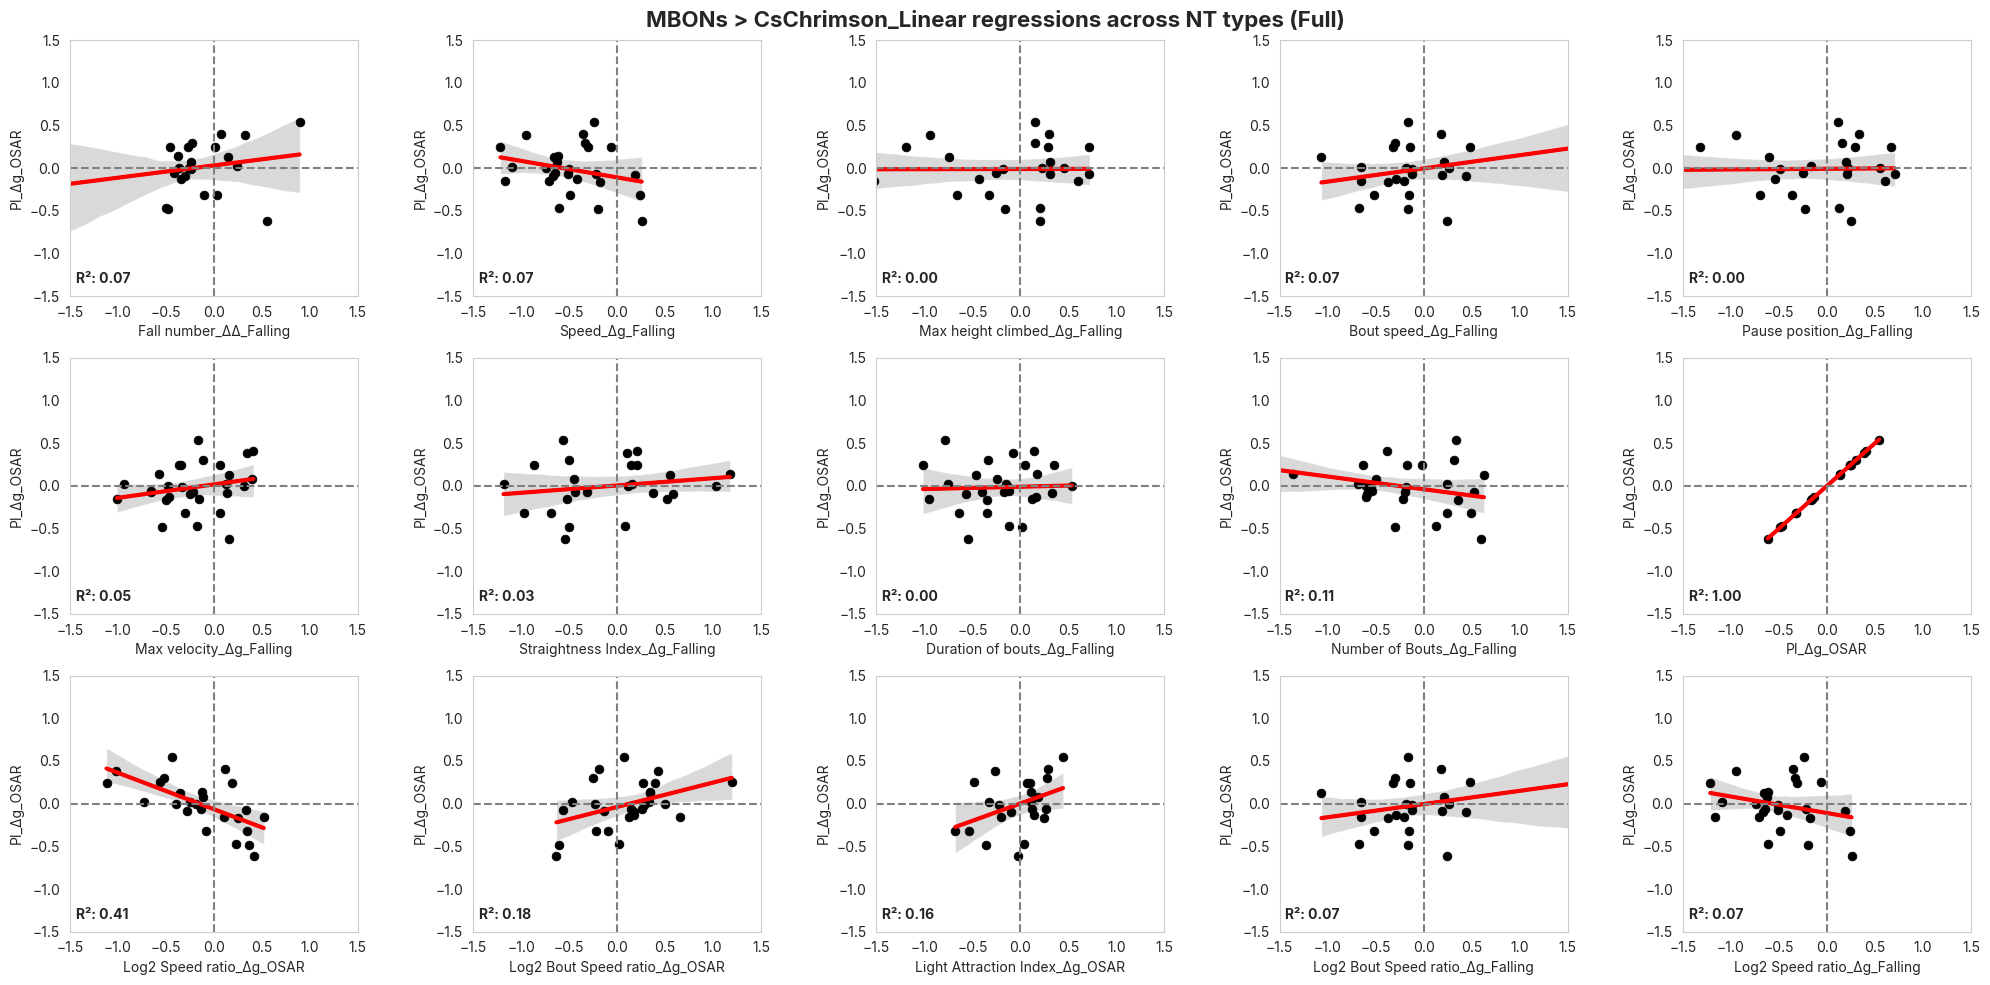

Generated plot for Full condition


In [69]:
import scipy.stats

plt.rcParams["font.family"] = "Inter"

responder = "Chrimson2"

# Define the three condition files
conditions = ['Half', 'Full']

for condition in conditions:
    # Read the specific condition file
    totalmetriccomparison = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Totalcomparisonofallmetrics-" + condition + ".xlsx")
    
    if responder == 'Chrimson2':
        responderrename = "CsChrimson"
        df_linereg = totalmetriccomparison[totalmetriccomparison['responder']=="Chrimson2"].reset_index(drop=True)
        colorline = 'red'
    
    if responder == 'ACR':
        responderrename = "GtACR1"
        df_linereg = totalmetriccomparison[totalmetriccomparison['responder']=="ACR"].reset_index(drop=True)
        colorline = 'green'
    
    totalmapplots = df_linereg.drop(columns = ['genotypeandresponder', 'responder'])
    df_totalmetrics_origin = totalmapplots[~totalmapplots['MBON'].isin(['VT999036'])]
    
    df_totalmetrics = df_totalmetrics_origin.drop(columns = ['MBON'])
    metrictype = df_totalmetrics.columns.tolist()
        
    figlinregplots, axes = plt.subplots(3,5, figsize=(20,10))
    axscatter_linreg = axes.flatten()
       
    for k,j in zip(metrictype, range(len(metrictype))):
  
        x_label_1 = k
        y_label_1 = 'PI_Δg_OSAR'      

        data_nt = df_totalmetrics_origin[~((df_totalmetrics_origin[x_label_1].abs() < 0.1) & (df_totalmetrics_origin[y_label_1].abs() < 0.2))].reset_index(drop=True)
        
        sns.regplot(x=x_label_1, y=y_label_1, data=data_nt, ci=95, scatter=False, line_kws={"color": "black"}, ax=axscatter_linreg[j])
        sns.regplot(x=x_label_1, y=y_label_1, data=data_nt, ci=0, scatter=False, line_kws={"color": colorline, 'lw': 3}, ax=axscatter_linreg[j])
        sns.scatterplot(x=x_label_1, y=y_label_1, data=data_nt, s=40, color= "black", edgecolors="face", ax=axscatter_linreg[j])

        axscatter_linreg[j].grid(False)
        axscatter_linreg[j].set_ylim([-1.5, 1.5])
        axscatter_linreg[j].set_xlim([-1.5, 1.5])
        axscatter_linreg[j].axvline(0, c=(.5, .5, .5), ls='--')
        axscatter_linreg[j].axhline(0, c=(.5, .5, .5), ls='--')
        
        axscatter_linreg[j].yaxis.set_tick_params(labelbottom=True)

        # Correlation for subplot
        pearsonscorrelation_cr2_1 = scipy.stats.pearsonr(data_nt[x_label_1], data_nt[y_label_1])
        # civallow_cr2_1 = pearsonscorrelation_cr2_1.confidence_interval(confidence_level=0.95)[0] 
        # civalhigh_cr2_1 = pearsonscorrelation_cr2_1.confidence_interval(confidence_level=0.95)[1]  
        # axscatter_linreg[j].annotate(f"R²: {(round(pearsonscorrelation_cr2_1[0],3))**2:.2f}" + "\nCI:" + str(round(civallow_cr2_1,3)) + ", " + str(round(civalhigh_cr2_1,3)), 
        #                         (0.02, 0.05), ha="left", xycoords='axes fraction', weight="bold", fontsize=8)
        axscatter_linreg[j].annotate(f"R²: {(round(pearsonscorrelation_cr2_1[0],3))**2:.2f}", 
                                (0.02, 0.05), ha="left", xycoords='axes fraction', weight="bold", fontsize=10)
    
            
    plt.tight_layout()
    plt.subplots_adjust(top=0.95, wspace=0.4)
    
    figlinregplots.suptitle(f"MBONs > {responderrename}_Linear regressions across NT types ({condition})", weight="bold", fontfamily="Inter", fontsize=16)
    
    plt.savefig(filesavedir + date + "_" + responder + "_linreg_allmetrics_" + condition + ".png", dpi=1200, bbox_inches='tight')
    plt.savefig(filesavedir + date + "_" + responder + "_linreg_allmetrics_" + condition + ".svg")
    
    plt.show()
    
    print(f"Generated plot for {condition} condition")

In [71]:
df_totalmetrics_origin

,Fall number_ΔΔ_Falling,Speed_Δg_Falling,Max height climbed_Δg_Falling,Bout speed_Δg_Falling,Pause position_Δg_Falling,Max velocity_Δg_Falling,Straightness Index_Δg_Falling,Duration of bouts_Δg_Falling,Number of Bouts_Δg_Falling,MBON,PI_Δg_OSAR,Log2 Speed ratio_Δg_OSAR,Log2 Bout Speed ratio_Δg_OSAR,Light Attraction Index_Δg_OSAR,Log2 Bout Speed ratio_Δg_Falling,Log2 Speed ratio_Δg_Falling
0,0.076,-0.350,0.293,0.184,0.336,0.412,0.210,0.146,-0.384,MB018B,0.402923,0.113780,-0.189276,0.284107,0.184,-0.350
1,-2.108,-0.706,0.597,-0.657,0.600,-1.009,0.517,0.122,-0.037,MB077B,-0.153291,0.103042,0.120246,0.098745,-0.657,-0.706
2,-0.010,-0.180,-0.088,-0.371,-0.030,-0.493,-0.034,-0.345,0.358,MB082C,-0.162254,0.254670,-0.043143,0.243158,-0.371,-0.180
3,0.148,-0.656,-0.744,-1.065,-0.608,0.162,0.553,-0.464,0.627,MB093C,0.130975,-0.347890,0.342316,-0.000772,-1.065,-0.656
4,-0.456,-0.307,0.285,-0.318,0.296,-0.362,0.209,0.048,-0.016,MB112C,0.244231,0.186355,0.392273,0.065169,-0.318,-0.307
5,-0.297,-0.670,-0.028,0.440,-0.082,-0.248,0.579,-0.562,-0.595,MB210B,-0.094999,0.066088,0.179836,-0.100782,0.440,-0.670
6,-0.341,-0.413,-0.435,-0.291,-0.546,-0.469,0.020,0.166,-0.600,MB242A,-0.131655,0.062215,0.178585,0.138073,-0.291,-0.413
7,-0.410,-0.645,-0.251,-0.068,-0.252,-0.653,-0.005,-0.120,-0.541,MB310C,-0.062308,-0.133325,0.141276,0.120539,-0.068,-0.645
8,-0.230,-0.334,0.148,-0.300,0.157,-0.111,-0.500,-0.342,0.318,MB319C,0.298763,-0.517077,-0.249884,0.281328,-0.300,-0.334
9,-0.009,-1.170,-1.525,-0.201,-1.563,-0.150,-0.521,-0.956,-0.213,MB323B,-0.156574,0.519993,0.656155,-0.205157,-0.201,-1.170


## Neurotransmitter types

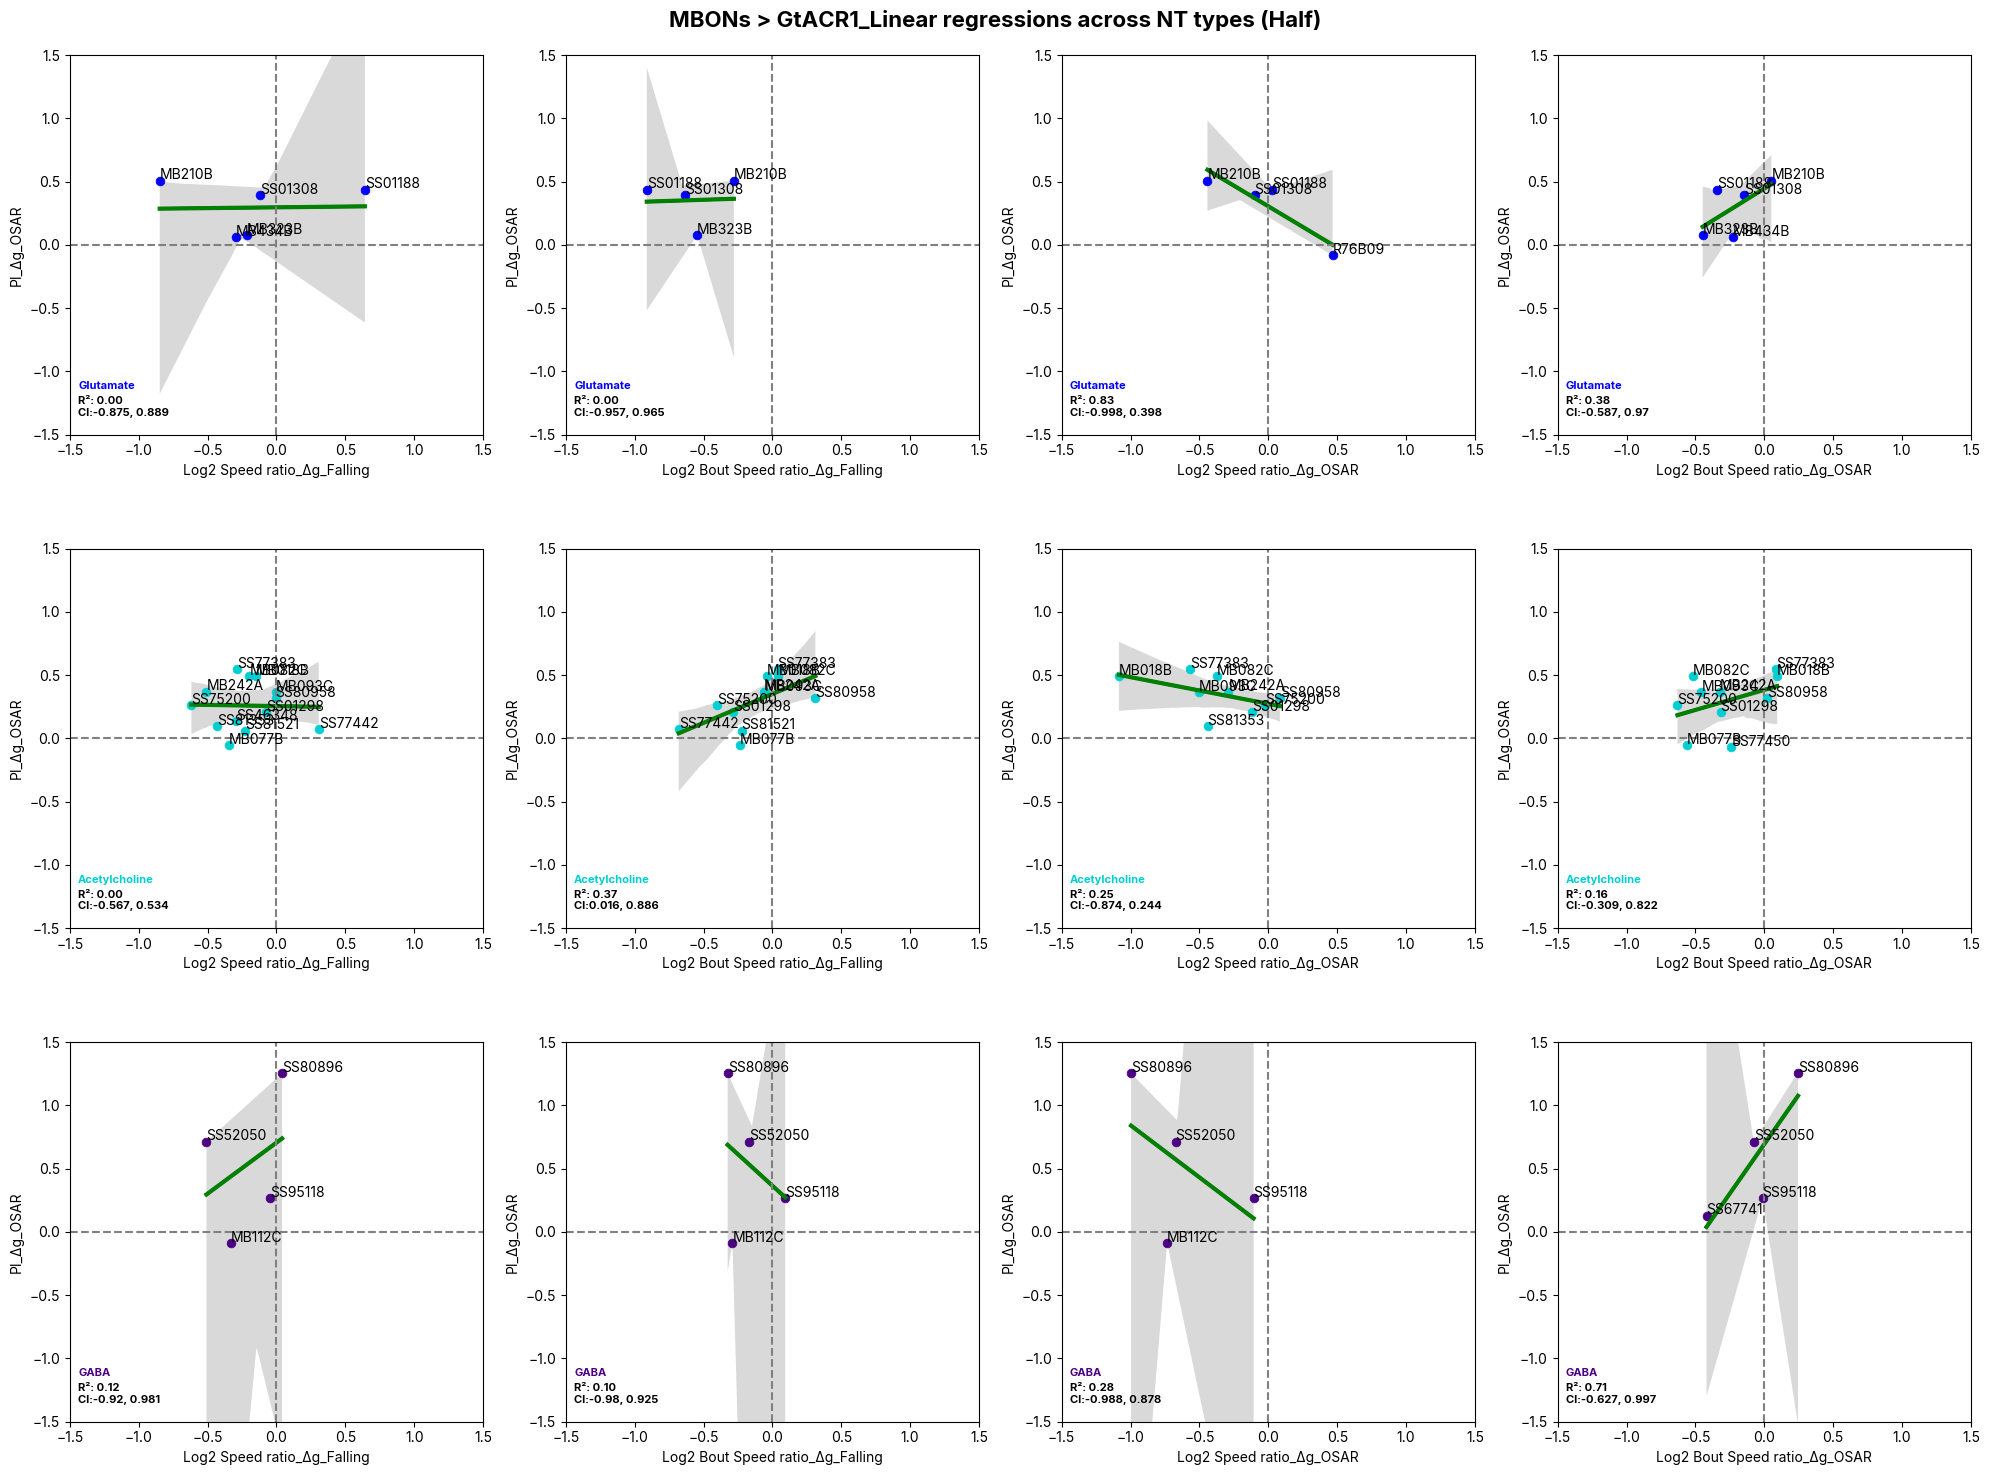

Generated plot for Half condition


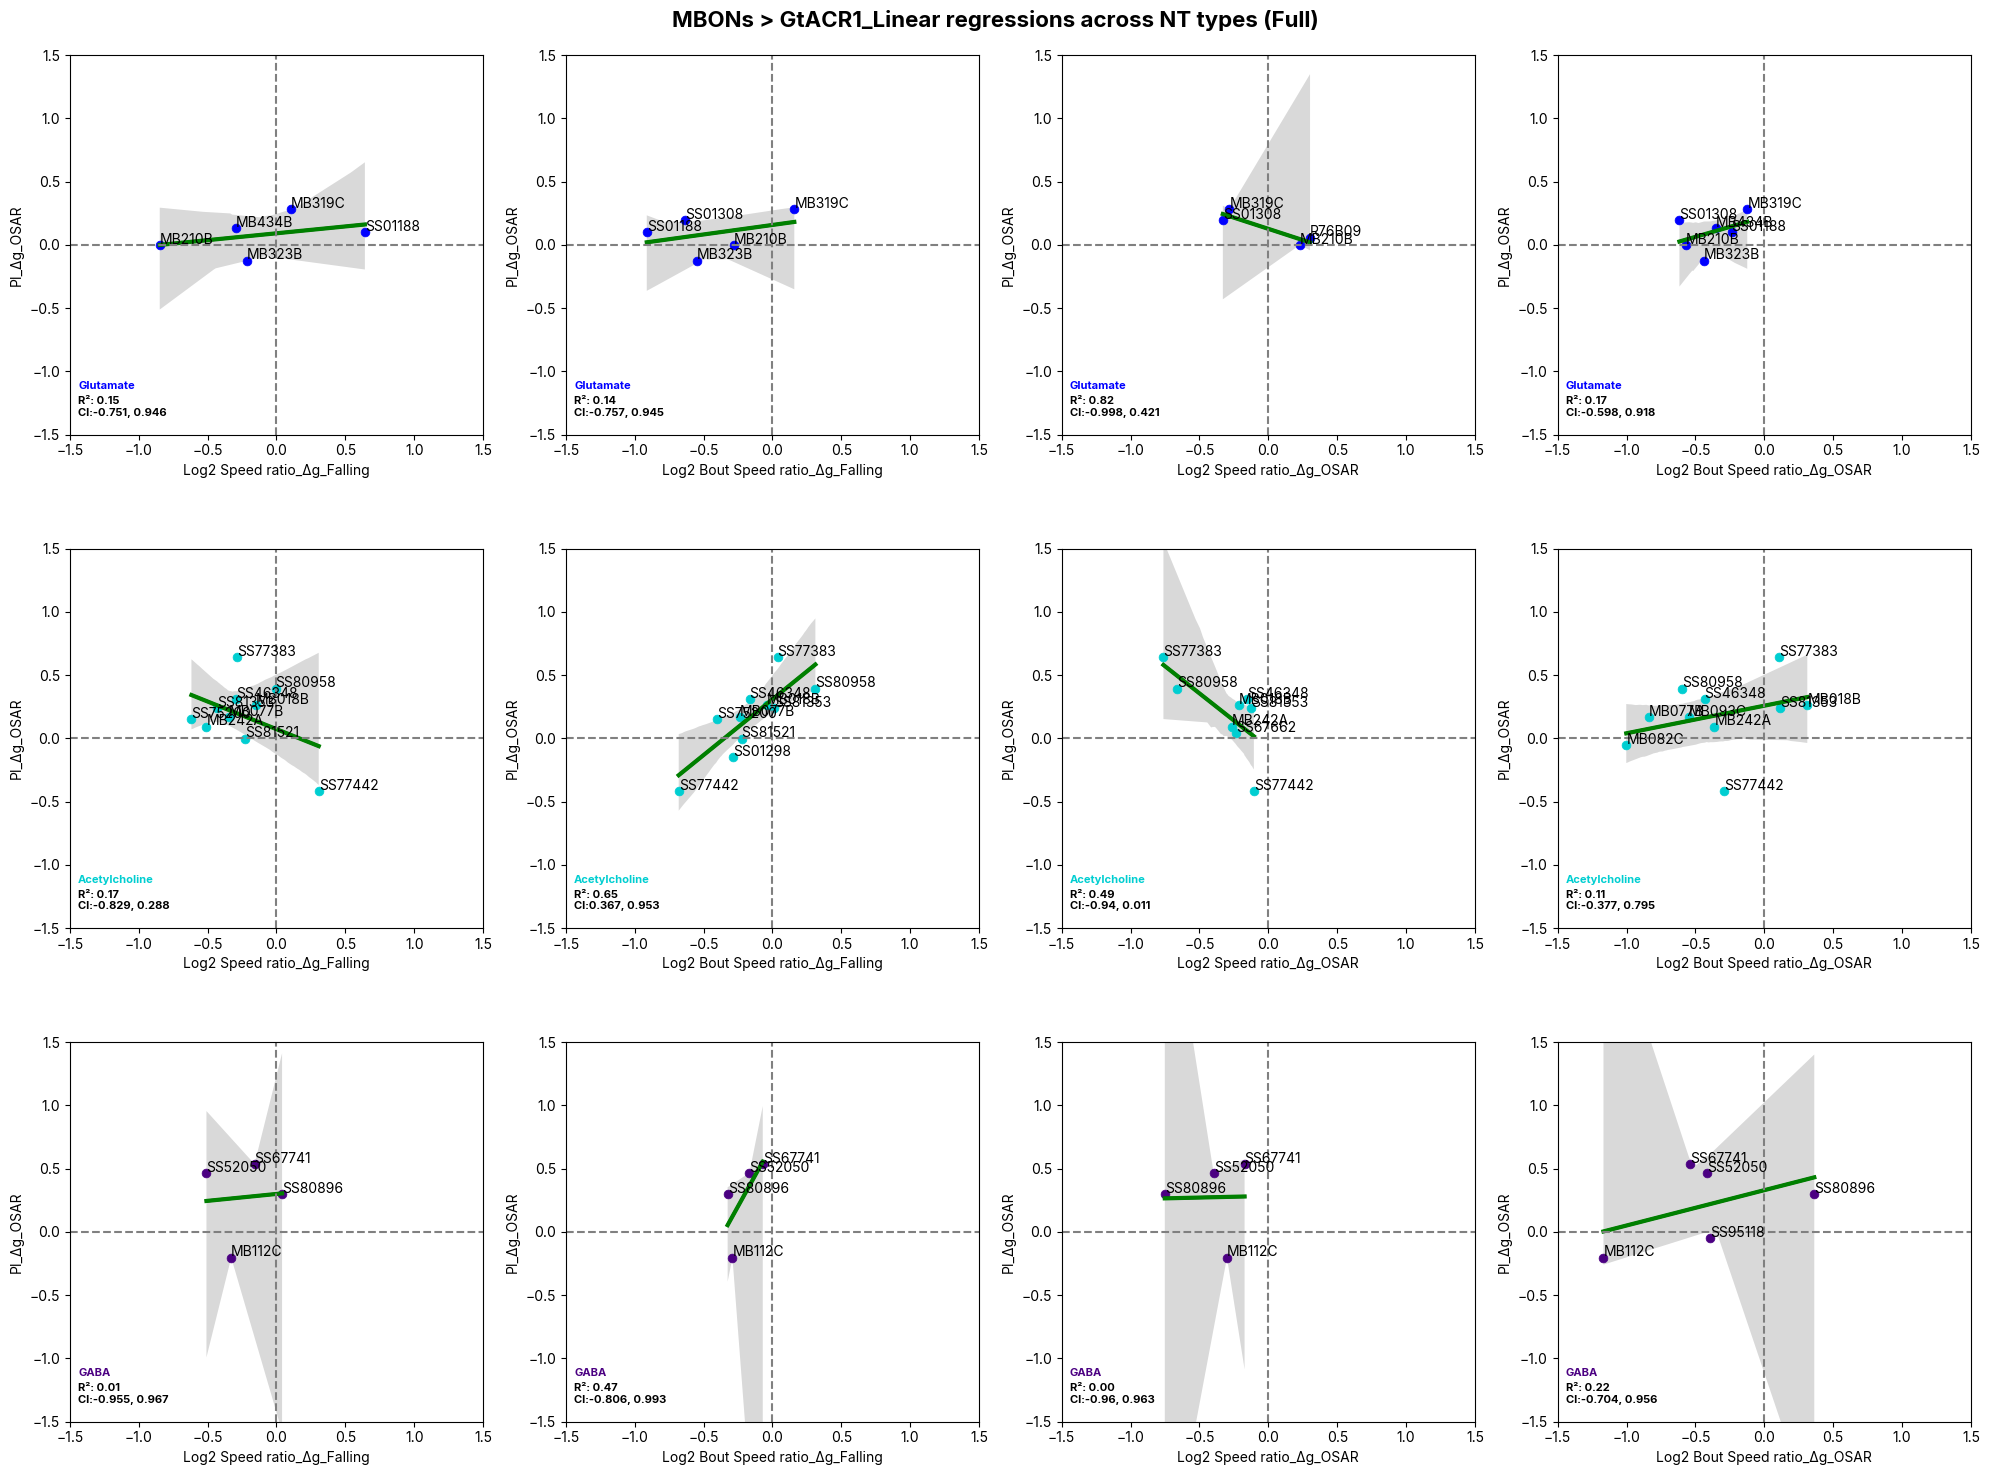

Generated plot for Full condition


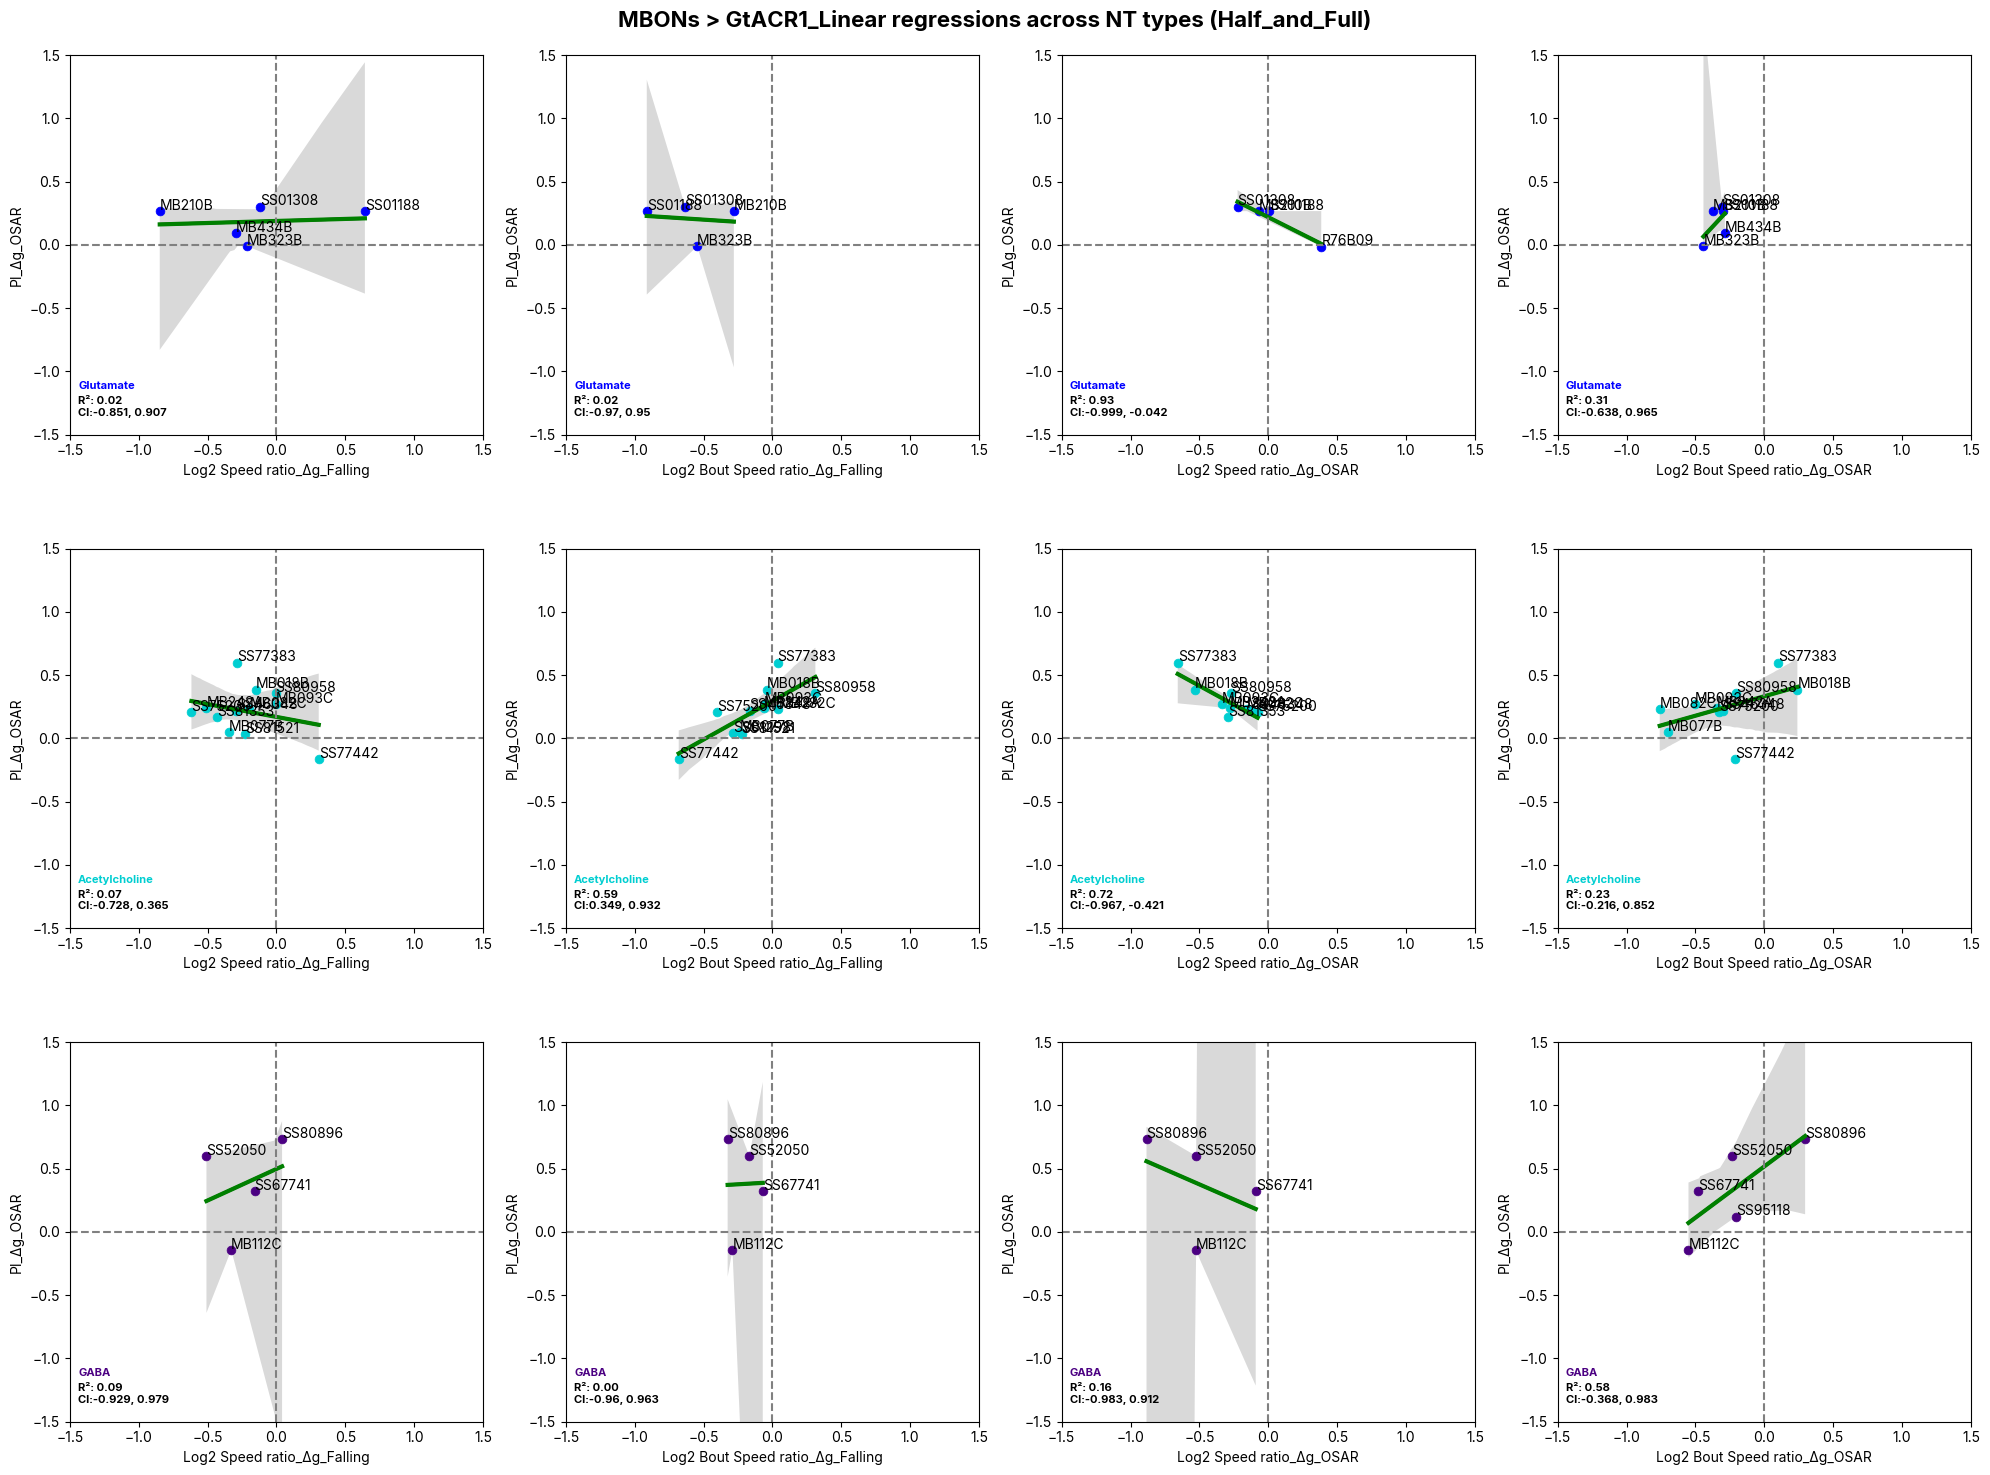

Generated plot for Half_and_Full condition


In [22]:
import scipy.stats

plt.rcParams["font.family"] = "Inter"

responder = "ACR"

# Define the three condition files
conditions = ['Half', 'Full', 'Half_and_Full']

for condition in conditions:
    # Read the specific condition file
    totalmetriccomparison = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Totalcomparisonofallmetrics-" + condition + ".xlsx")
    
    df_nt2 = totalmetriccomparison.drop(columns=['genotypeandresponder'])
    df_nt2 = df_nt2[~df_nt2['MBON'].isin(['VT999036'])]
    
    ntloblist = []
    mbonloclst = []
    df_nttotal = df_nt2.copy()
    for n in df_nt2['MBON']:    
        ntloblist.append(lobelocation[lobelocation['MBON'] == n]['Neurotransmitter'].values[0])
        mbonloclst.append(lobelocation[lobelocation['MBON'] == n]['MBON number'].values[0])
    df_nttotal['NT'] = ntloblist
    df_nttotal['Name'] = mbonloclst
    
    if responder == 'Chrimson2':
        responderrename = "CsChrimson"
        df_neurotrans = df_nttotal[df_nttotal['responder']=="Chrimson2"].sort_values(by="PI_Δg_OSAR", ascending=True).reset_index(drop=True)
        colorline = 'red'
        nttypes_color = ['mediumorchid', "darkorange", "slategrey"]
    
    if responder == 'ACR':
        responderrename = "GtACR1"
        df_neurotrans = df_nttotal[df_nttotal['responder']=="ACR"].sort_values(by="PI_Δg_OSAR", ascending=True).reset_index(drop=True)
        colorline = 'green'
        nttypes_color = ['blue', "darkturquoise", "indigo"]
    
    
    figntplot, axes = plt.subplots(3,4, figsize=(20,15))
    axscatter_nt = axes.flatten()
    nttypes = ['Glutamate', "Acetylcholine", "GABA"]
    
    metrictype = ['Log2 Speed ratio_Δg_Falling', 'Log2 Bout Speed ratio_Δg_Falling', 'Log2 Speed ratio_Δg_OSAR', 'Log2 Bout Speed ratio_Δg_OSAR']
    plotcounter = 0
    
    for n,j in zip(nttypes, nttypes_color):
        unfiltered_dfnt = df_neurotrans[df_neurotrans['NT'] == n].reset_index(drop=True)
        
        for k in metrictype:
            x_label_1 = k
            y_label_1 = 'PI_Δg_OSAR'      

            data_nt = unfiltered_dfnt[~((unfiltered_dfnt[x_label_1].abs() < 0.2) & (unfiltered_dfnt[y_label_1].abs() < 0.2))].reset_index(drop=True)
            #data_nt = unfiltered_dfnt.copy()
          
            sns.regplot(x=x_label_1, y=y_label_1, data=data_nt, ci=95, scatter=False, line_kws={"color": "black"}, ax=axscatter_nt[plotcounter])
            sns.regplot(x=x_label_1, y=y_label_1, data=data_nt, ci=0, scatter=False, line_kws={"color": colorline, 'lw': 3}, ax=axscatter_nt[plotcounter])
            sns.scatterplot(x=x_label_1, y=y_label_1, data=data_nt, s=40, color=j, edgecolors="face", ax=axscatter_nt[plotcounter])
    
            axscatter_nt[plotcounter].grid(False)
            axscatter_nt[plotcounter].set_ylim([-1.5, 1.5])
            axscatter_nt[plotcounter].set_xlim([-1.5, 1.5])
            axscatter_nt[plotcounter].axvline(0, c=(.5, .5, .5), ls='--')
            axscatter_nt[plotcounter].axhline(0, c=(.5, .5, .5), ls='--')
           
            axscatter_nt[plotcounter].yaxis.set_tick_params(labelbottom=True)
    
            for m, p in enumerate(data_nt['MBON']):
                axscatter_nt[plotcounter].annotate(p, (data_nt.loc[m,x_label_1], data_nt.loc[m,y_label_1]+0.01), fontsize=10)
    
            # Correlation for subplot
            pearsonscorrelation_cr2_1 = scipy.stats.pearsonr(data_nt[x_label_1], data_nt[y_label_1])
            civallow_cr2_1 = pearsonscorrelation_cr2_1.confidence_interval(confidence_level=0.95)[0] 
            civalhigh_cr2_1 = pearsonscorrelation_cr2_1.confidence_interval(confidence_level=0.95)[1]  
            axscatter_nt[plotcounter].annotate(f"R²: {(round(pearsonscorrelation_cr2_1[0],3))**2:.2f}" + "\nCI:" + str(round(civallow_cr2_1,3)) + ", " + str(round(civalhigh_cr2_1,3)), 
                                    (0.02, 0.05), ha="left", xycoords='axes fraction', weight="bold", fontsize=8)
            
            # Naming of nt type
            axscatter_nt[plotcounter].annotate(n, (0.02, 0.12), ha="left", xycoords='axes fraction', color=j, weight="bold", fontsize=8)
            plotcounter += 1
            
    plt.tight_layout()
    plt.subplots_adjust(top=0.95, wspace=0.2, hspace=0.3)
    
    figntplot.suptitle(f"MBONs > {responderrename}_Linear regressions across NT types ({condition})", weight="bold", fontfamily="Inter", fontsize=16)
    
    plt.savefig(filesavedir + date + "_" + responder + "_linreg_nttypes_" + condition + ".png", dpi=1200, bbox_inches='tight')
    plt.savefig(filesavedir + date + "_" + responder + "_linreg_nttypes_" + condition + ".svg")
    
    plt.show()
    
    print(f"Generated plot for {condition} condition")

## poster only

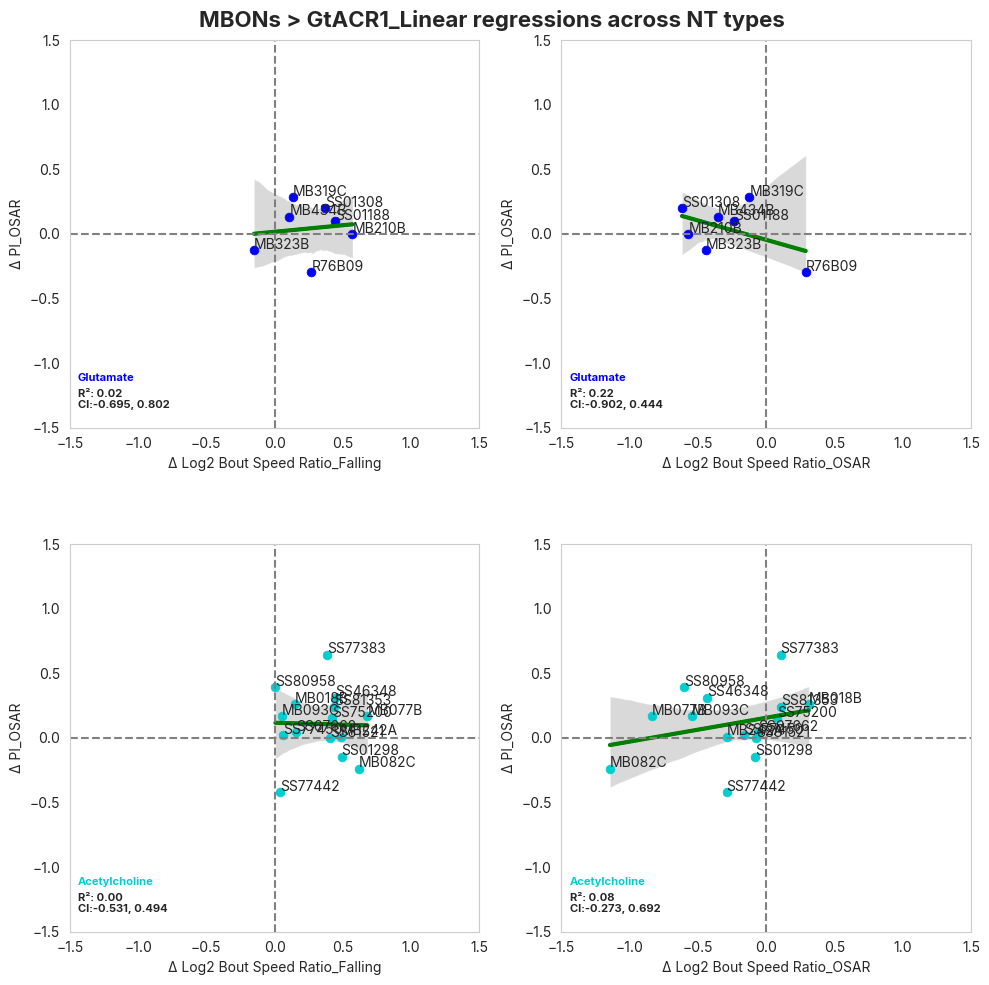

In [73]:
##for poster only

import scipy.stats

plt.rcParams["font.family"] = "Inter"

responder = "ACR"

if responder == 'Chrimson2':
    responderrename = "CsChrimson"
    df_neurotrans = df_nttotal[df_nttotal['responder']=="Chrimson2"].sort_values(by = "Δ PI_OSAR", ascending=True).reset_index(drop=True)
    colorline = 'red'
    nttypes_color = ['mediumorchid', "darkorange", "slategrey"]

if responder == 'ACR':
    responderrename = "GtACR1"
    df_neurotrans = df_nttotal[df_nttotal['responder']=="ACR"].sort_values(by = "Δ PI_OSAR", ascending=True).reset_index(drop=True)
    colorline = 'green'
    nttypes_color = ['blue', "darkturquoise", "indigo"]


figntplot, axes = plt.subplots(2,2, figsize=(10,10))
axscatter_nt = axes.flatten()
nttypes = ['Glutamate', "Acetylcholine"]

metrictype = ['Δ Log2 Bout Speed Ratio_Falling','Δ Log2 Bout Speed Ratio_OSAR']
plotcounter = 0

for n,j in zip(nttypes, nttypes_color):
    unfiltered_dfnt = df_neurotrans[df_neurotrans['NT'] == n].reset_index(drop=True)
    
    for k in metrictype:
        x_label_1 = k
        y_label_1 = 'Δ PI_OSAR'      

        #data_nt = unfiltered_dfnt[~((unfiltered_dfnt[x_label_1] < 0.2) & (unfiltered_dfnt[y_label_1] < 0.2))].reset_index(drop=True)
        data_nt = unfiltered_dfnt.copy()
      
        sns.regplot(x=x_label_1, y=y_label_1, data=data_nt, ci = 95, scatter = False, line_kws={"color": "black"}, ax=axscatter_nt[plotcounter]) #ci color
        sns.regplot(x=x_label_1, y=y_label_1, data=data_nt, ci = 0, scatter = False, line_kws={"color": colorline, 'lw': 3}, ax=axscatter_nt[plotcounter])  #line color
        sns.scatterplot(x=x_label_1, y=y_label_1, data=data_nt, s = 40, color = j, edgecolors = "face", ax=axscatter_nt[plotcounter])

        axscatter_nt[plotcounter].grid(False)
        axscatter_nt[plotcounter].set_ylim([-1.5, 1.5])
        axscatter_nt[plotcounter].set_xlim([-1.5, 1.5])
        axscatter_nt[plotcounter].axvline(0, c=(.5, .5, .5), ls= '--')
        axscatter_nt[plotcounter].axhline(0, c=(.5, .5, .5), ls= '--')
       
        axscatter_nt[plotcounter].yaxis.set_tick_params(labelbottom=True)

        for m, p in enumerate(data_nt['MBON']):
            axscatter_nt[plotcounter].annotate(p, (data_nt.loc[m,x_label_1], data_nt.loc[m,y_label_1]+0.01), fontsize = 10)

        #correlation for subplot
        pearsonscorrelation_cr2_1 = scipy.stats.pearsonr(data_nt[x_label_1], data_nt[y_label_1]) #correlation instead of linear regression: trying to find the relationship rather than causation    
        civallow_cr2_1 = pearsonscorrelation_cr2_1.confidence_interval(confidence_level=0.95)[0] 
        civalhigh_cr2_1 = pearsonscorrelation_cr2_1.confidence_interval(confidence_level=0.95)[1]  
        axscatter_nt[plotcounter].annotate(f"R²: {(round(pearsonscorrelation_cr2_1[0],3))**2:.2f}" + "\nCI:" + str(round(civallow_cr2_1,3)) + ", " + str(round(civalhigh_cr2_1,3)), (0.02, 0.05), 
                                ha = "left", xycoords = 'axes fraction', weight = "bold", fontsize = 8)
        
        #naming of nt type
        axscatter_nt[plotcounter].annotate(n, (0.02, 0.12), ha="left", xycoords='axes fraction', color= j, weight="bold", fontsize=8)
        plotcounter +=1
        
plt.tight_layout()
plt.subplots_adjust(top = 0.95, wspace=0.2, hspace = 0.3)

figntplot.suptitle("MBONs > " + responderrename + "_Linear regressions across NT types ", weight = "bold", fontfamily = "Inter", fontsize = 16)

plt.savefig(filesavedir + "temp.png", dpi = 1200, bbox_inches='tight')
